---
>「自分が話している対象を測定し、数値で表すことができるなら、それについて何かを知っていることになる」
>
> ケルヴィン卿（ウィリアム・トムソン）

---

# 推論サービング — 学習済みモデルを利用者に届けるまで

本テキストでは、学習済みのモデル、特に大規模言語モデル（LLM）を、**利用者にサービスとして提供する側**の技術を学ぶ

「運用」の章では、共有GPUサーバで学習を安全に回す方法を扱った
学習が終わったモデルは、そのままでは誰の役にも立たない
利用者からの要求を受け取り、決められた時間内に、決められた費用で、止まらずに応答を返し続けて初めて価値が生まれる

この「応答を返し続ける仕組み」を**推論サービング**（inference serving）と呼ぶ

本テキストでは、Colabの無償GPU（T4）で動く小型の公開LLMを使い、すべてを**実測して理解する**

1. **学習と推論提供の違い**: 何を最適化するのか
2. **推論サーバを立てる**: OpenAI互換に近いHTTPエンドポイントとストリーミング応答
3. **指標を測る**: TTFT、トークン間隔、毎秒トークン数、パーセンタイル
4. **同時実行とバッチ処理**: 負荷試験の自作とスループット対遅延の曲線
5. **専用の推論エンジン**: vLLMなどが解決する問題
6. **量子化して提供する**: メモリ、速度、出力品質の変化
7. **キャッシュ**: KVキャッシュ、応答キャッシュ、プロンプト先頭の共有
8. **ルーティングとフォールバック**: 小さいモデルと大きいモデルの使い分け
9. **監視と段階的な公開**: ログ、カナリア公開、再試行、レート制限
10. **コストの見積もり**: 1リクエストあたりの原価と損益分岐
11. **Colabでは実習できない範囲**: 自動スケール、複数リージョン、障害注入試験

---

# この講義でできるようになること

- 小型のLLMをHTTPサーバとして公開し、ストリーミングで応答を返せるようになる
- TTFT、毎秒トークン数、p95遅延を自分で測り、数値で性能を語れるようになる
- 負荷試験を自作し、スループットと遅延のトレードオフを曲線として描けるようになる
- 量子化、キャッシュ、ルーティングの効果を、思い込みではなく実測で判断できるようになる
- 1リクエストあたりの原価を式で見積もり、自前運用とAPI利用を比較できるようになる

# 全体像

本テキストで作るものと測るものの流れを先に示す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-overview.png" width=700>

上の図の上段が2節で作る推論サーバ、下段がそのサーバに対して以降の節で行うことである

1. 小型LLMを `transformers` で読み込む
2. FastAPIで包み、`/v1/chat/completions` として公開する（別プロセスで起動し、最後に停止する）
3. ノートブックからリクエストを投げ、1件の遅延を分解して測る
4. 同時リクエスト数を増やし、サーバが飽和する様子を見る
5. バッチ処理、量子化、キャッシュ、ルーティングで改善し、そのたびに測り直す
6. ログから誤り率と遅延を監視し、新しい版を少しずつ公開する
7. 測ったスループットから原価を計算する

一貫した方針は「**変更したら必ず測る**」である
推論の高速化手法は数多くあるが、どれが効くかはモデル、GPU、要求の分布によって変わる
本テキストに書かれた傾向も、自分の環境で測って確かめてほしい

## 既存の章との関係

本テキストは、次の章の内容を前提にする、または補い合う

| 章 | ファイル | 本テキストとの関係 |
| --- | --- | --- |
| 運用 | `mlsys-text-R-運用.ipynb` | 学習側の運用（tmux、uv、wandb、チェックポイント）を扱う、本テキストはその続編である |
| LLM-1 Basics | `mlsys-text-M-LLM-1-Basics.ipynb` | KV Cache、量子化、Speculative Decoding、vLLM、TensorRT-LLMの**概念** |
| NLP-6 GPT-full | `mlsys-text-J-NLP-6-GPT-full.ipynb` | PagedAttention、量子化手法（GPTQ、AWQなど）、KVキャッシュ削減の**仕組み** |
| NLP-8 LLM調整 | `mlsys-text-J-NLP-8-LLM調整.ipynb` | 指示チューニング、LoRA、DPOでモデルを調整する章で、調整したモデルが、本テキストで公開する「新しい版」になる |
| LLM-2 Application | `mlsys-text-M-LLM-2-Application.ipynb` | 「キャッシュとコスト」の節が、**APIを使う側**から見た課金の式、プロンプトキャッシュ、意味キャッシュを扱う |
| LLM-4 評価 | `mlsys-text-M-LLM-4-評価.ipynb` | 評価データの設計、統計的な誤差、回帰試験を扱い、本テキストで「品質」を測る箇所の土台である |
| LLM-5 Agent設計 | `mlsys-text-M-LLM-5-Agent設計.ipynb` | 「可観測性」の節が、1つの依頼の内側（LLM呼び出しとツール実行）を記録するトレーサを扱う |

本テキストはこれらの内容を繰り返さず、**提供する側から見て何がどれだけ変わるか**を測ることに集中する
以降では、それぞれを「運用」の章、「LLM-4 評価」の章のように呼ぶ

---

# 1. 学習と推論提供の違い

学習と推論提供は、同じモデルと同じGPUを使うが、仕事の性質がまったく異なる

| 観点 | 学習 | 推論提供 |
| --- | --- | --- |
| 仕事の形 | 1つの長い仕事（数時間〜数日） | 無数の短い仕事（数十ミリ秒〜数十秒） |
| 入力 | 手元にそろったデータセット | いつ来るか分からない利用者の要求 |
| バッチサイズ | 自分で決める | 到着の仕方で決まる |
| 最適化の対象 | 損失、学習にかかる総時間 | 遅延、スループット、コスト、可用性 |
| 失敗したとき | チェックポイントから再開する | 利用者にエラーが見える |
| 計算の向き | 順伝播と逆伝播 | 順伝播のみ（勾配は不要） |
| 利用の波 | 一定（GPUを使い切る） | 昼夜や曜日で大きく変動する |

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-train-vs-serve.png" width=680>

上の図のように、学習は1つの長い仕事であり、推論提供は不規則に届く多数の短い仕事である

学習は「全体が早く終わればよい」ので、途中の1ステップが遅れても問題にならない
推論提供は「**1件ごとの待ち時間**」が利用者の体験になるので、平均だけでなく遅い側の値が重要になる

## 何を最適化するのか

推論提供で見る指標は、大きく4つに分けられる

- **遅延**（latency）: 1件の要求を出してから応答が返るまでの時間
    - LLMでは「最初の1文字が出るまで」と「出始めてからの速さ」を分けて考える（3節）
- **スループット**（throughput）: 単位時間に処理できる量
    - 毎秒リクエスト数（requests per second）や毎秒トークン数（tokens per second）で表す
- **コスト**（cost）: 1件の要求を処理するのにかかる費用
    - GPUの時間単価をスループットで割ると求まる（10節）
- **可用性**（availability）: サービスが正しく応答している時間の割合
    - 誤り率（エラーを返した要求の割合）と表裏の関係にある

これらに対して「p95遅延を2秒以内にする」「誤り率を0.1%未満にする」のような目標値を決める
この目標値を**SLO**（Service Level Objective、サービス水準目標）と呼ぶ

SLOを先に決めるのは、最適化の終わりを決めるためである
目標がなければ、どこまで速くすればよいか、どこからが作り込みすぎかを判断できない

## 指標どうしの綱引き

4つの指標は同時には良くならない

- スループットを上げるために要求をまとめて処理すると、まとまるのを待つ分だけ遅延が増える
- 遅延を下げるためにGPUを余らせておくと、コストが上がる
- コストを下げるために小さいモデルや量子化を使うと、出力の品質が下がることがある
- 可用性を上げるために予備の系を用意すると、コストが上がる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-four-metrics.png" width=600>

上の図の矢印は、一方を良くすると他方が悪くなる関係を示している

推論サービングの設計とは、この綱引きの中で**SLOを満たす最も安い点を探す作業**である
以降の節では、それぞれの綱引きを1つずつ実測する

---

# 準備

必要なライブラリを導入する

- `transformers`、`accelerate`: モデルの読み込み
- `bitsandbytes`: 4bit／8bit量子化（6節）
- `fastapi`、`uvicorn`: HTTPサーバ
- `requests`: ノートブックからリクエストを投げるクライアント

ランタイムはGPU（T4）を選ぶ
CPUでも大半のセルは動くが、量子化の節はGPUが必要である

In [1]:
# 推論サーバと量子化に必要なライブラリを導入する
!pip install -q transformers accelerate bitsandbytes fastapi uvicorn requests

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 14.6 MB/s eta 0:00:00


In [2]:
# 共通のライブラリを読み込み、乱数シードと実行デバイスを決める
import os, sys, re, gc, copy, json, math, time, random, hashlib, subprocess
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import torch
import requests
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

device: cuda
GPU: Tesla T4


## 使うモデル

鍵なしで取得できる小型の公開モデルを2つ使う

| 役割 | モデル | パラメータ数 | 使う節 |
| --- | --- | --- | --- |
| 小さいモデル | `Qwen/Qwen2.5-0.5B-Instruct` | 約5億 | 全体 |
| 大きいモデル | `Qwen/Qwen2.5-1.5B-Instruct` | 約15億 | 6節、8節 |

- どちらも対話用に調整されたモデルで、トークナイザとチャットテンプレートが共通である
- 実用のLLMに比べるとはるかに小さく、答えの質は高くない
- しかし構造は同じ自己回帰型のTransformerであり、**遅延やスループットの振る舞いは大きいモデルと同じ形**になる

読み込みの関数 `load_model` は、後の量子化の節でも使えるように `quant` 引数を持たせておく

In [3]:
# モデルを読み込む関数を定義し、小さいモデルを読み込む
SMALL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
LARGE_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

def load_model(name, quant=None):
    """quant は None（GPUでは半精度）、"8bit"、"4bit" のいずれか"""
    if quant is None:
        model = AutoModelForCausalLM.from_pretrained(name)
        if device.type == "cuda":
            model = model.half().to(device)
    else:
        from transformers import BitsAndBytesConfig
        if quant == "8bit":
            cfg = BitsAndBytesConfig(load_in_8bit=True)
        else:
            cfg = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
                                     bnb_4bit_compute_dtype=torch.float16)
        model = AutoModelForCausalLM.from_pretrained(name, quantization_config=cfg, device_map={"": 0})
    return model.eval()

tok = AutoTokenizer.from_pretrained(SMALL_NAME)
small = load_model(SMALL_NAME)

# 生成を打ち切るトークン（モデルが「発話の終わり」を示すID）
eos = small.generation_config.eos_token_id
EOS_IDS = set(eos if isinstance(eos, list) else [eos])
print("parameters: %.0fM" % (sum(p.numel() for p in small.parameters()) / 1e6))
print("EOS ids:", EOS_IDS)

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

parameters: 494M
EOS ids: {151643, 151645}


## 生成の関数を自分で書く

`model.generate` を使えば1行で生成できるが、本テキストでは**生成の内側の時間を測りたい**
そこで、貪欲法（greedy decoding、毎回もっとも確率の高いトークンを選ぶ）の生成ループを自分で書く

LLMの生成は2つの段階に分かれる

- **prefill**（前処理）: プロンプト全体を1回の順伝播で処理し、KVキャッシュを作り、最初の1トークンを決める
- **decode**（逐次生成）: 直前の1トークンだけを入力し、KVキャッシュを使って次の1トークンを決める
    - これを出力の長さだけ繰り返す

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-prefill-decode.png" width=720>

上の図の左がprefill、右がdecodeである
prefillは入力のトークンをまとめて1回で処理し、decodeは出力した1トークンを次の入力にして1ステップずつ進む

KVキャッシュの仕組みは「LLM-1 Basics」の章を参照
ここでは「過去のトークンの計算結果を取っておき、新しい1トークン分だけ計算する」と理解しておけばよい

GPUの計算は非同期に進むので、時間を測る直前に `torch.cuda.synchronize()` で計算の完了を待つ
これを忘れると、実際より短い時間が測れてしまう

In [4]:
# 貪欲法の生成ループを自作し、prefill と各 decode ステップの時間を測れるようにする
def sync():
    if device.type == "cuda":
        torch.cuda.synchronize()

def build_ids(question, system=None):
    """チャットテンプレートを適用してトークンIDの列にする"""
    msgs = ([{"role": "system", "content": system}] if system else []) + [{"role": "user", "content": question}]
    text = tok.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    return tok(text, return_tensors="pt").input_ids.to(device)

@torch.inference_mode()
def greedy_decode(model, ids, max_new=32, past=None, stop_at_eos=True):
    """ids は (バッチ, 長さ)、past を渡すと、その続きとして ids を処理する"""
    sync(); t0 = time.perf_counter()
    out = model(input_ids=ids, past_key_values=past, use_cache=True)   # prefill
    logits = out.logits[:, -1].float()
    sync(); t_prefill = time.perf_counter() - t0

    tokens, step_times, confs = [], [], []
    for _ in range(max_new):
        nxt = logits.argmax(-1)
        if stop_at_eos and nxt[0].item() in EOS_IDS:
            break
        tokens.append(nxt[0].item())
        confs.append(torch.softmax(logits[0], -1).max().item())      # 選んだトークンの確率
        t1 = time.perf_counter()
        out = model(input_ids=nxt[:, None], past_key_values=out.past_key_values, use_cache=True)  # decode 1ステップ
        logits = out.logits[:, -1].float()
        sync(); step_times.append(time.perf_counter() - t1)
    return {"text": tok.decode(tokens, skip_special_tokens=True), "tokens": tokens,
            "t_prefill": t_prefill, "step_times": step_times,
            "t_total": t_prefill + sum(step_times),
            "conf": float(np.mean(confs)) if confs else 0.0}

# 最初の1回は初期化の時間が混ざるので、測定の前に捨てる（ウォームアップ）
greedy_decode(small, build_ids("Hello"), max_new=4)
r = greedy_decode(small, build_ids("推論サービングとは何かを1文で説明してください"), max_new=48)
print(r["text"])
print("prefill %.1f ms, decode %.1f ms/token, tokens %d" % (
    r["t_prefill"] * 1e3, np.mean(r["step_times"]) * 1e3, len(r["tokens"])))

推論サービングは、データの分析やモデルの推定に使用されるためのアルゴリズムの一種です。このアルゴリズムは、データのパターンや関係性を分析し、予
prefill 99.1 ms, decode 107.9 ms/token, tokens 48


---

# 2. 推論サーバを立てる

ノートブックの中で `greedy_decode` を呼べば答えは得られるが、これは「サービス」ではない
利用者は別のマシンから、別のプログラム言語から、同時に何人も要求を送ってくる
そのため、モデルをHTTPサーバの後ろに置く

## 目標とする形

- `POST /v1/chat/completions` に、`messages`（対話の履歴）と `max_tokens` をJSONで送ると、応答がJSONで返る
- `stream: true` を付けると、生成されたトークンが順に届く
- `GET /health` で、サーバが応答できる状態かを確認できる

この形は、OpenAIのChat Completions APIが広めたもので、多くの推論エンジンやクライアントが同じ形を採用している
形をそろえておくと、**クライアントのコードを変えずに、背後のモデルやエンジンを取り替えられる**
本テキストのサーバは必要最小限の項目だけを実装した「互換に近い」ものである

## サーバの設計

GPUは1つしかないので、複数の要求が同時に来ても、モデルの順伝播を好き勝手に走らせるわけにはいかない
そこで次の構成にする

1. HTTPの受付（FastAPI）は、要求を検査して**待ち行列**（queue）に入れるだけにする
2. GPUを使うのは**1本の作業スレッド**だけにする
    - 待ち行列から要求を取り出し、生成を実行する
3. 生成されたトークンは、要求ごとの受け渡し口を通して受付側に戻し、利用者へ送る

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-server-architecture.png" width=720>

上の図では、左から右へ要求が流れ、下の経路でトークンが受付へ戻る

受付と生成を分ける理由は2つある

- 生成中も新しい要求を受け付け、`/health` に答え続けられる
- 作業スレッドが「待ち行列から何件取り出すか」を決めるだけで、逐次処理とバッチ処理を切り替えられる（4節）

設定は環境変数で渡す
`MAX_BATCH`（まとめて処理する最大件数）、`FAIL_RATE`（わざと失敗させる割合）、`RATE_LIMIT_RPS`（毎秒の受付上限）などは後の節で使う

In [5]:
# サーバ本体を serve_app.py として書き出す（このセルはファイルを作るだけで、まだ起動しない）
SERVER_CODE = r'''
# serve_app.py: 小型LLMをOpenAI互換に近い形で公開する最小の推論サーバ
import os, time, json, uuid, queue, random, asyncio, threading
import torch
from fastapi import FastAPI
from fastapi.responses import JSONResponse, StreamingResponse
from pydantic import BaseModel
from transformers import AutoTokenizer, AutoModelForCausalLM

# ---- 設定（環境変数で受け取る）
MODEL_NAME     = os.environ.get("MODEL_NAME", "Qwen/Qwen2.5-0.5B-Instruct")
VERSION        = os.environ.get("VERSION", "v1")             # ログに残す版の名前
MAX_BATCH      = int(os.environ.get("MAX_BATCH", "1"))       # まとめて処理する最大件数
BATCH_WAIT_MS  = float(os.environ.get("BATCH_WAIT_MS", "10"))  # 仲間が集まるのを待つ時間
MAX_QUEUE      = int(os.environ.get("MAX_QUEUE", "64"))      # 待ち行列の上限
RATE_LIMIT_RPS = float(os.environ.get("RATE_LIMIT_RPS", "0"))  # 毎秒の受付上限（0 は無制限）
RATE_BURST     = float(os.environ.get("RATE_BURST", "5"))    # 一時的に許す超過分
FAIL_RATE      = float(os.environ.get("FAIL_RATE", "0"))     # 障害の模擬: この割合で 500 を返す
EXTRA_DELAY_MS = float(os.environ.get("EXTRA_DELAY_MS", "0"))  # 性能劣化の模擬: 受付で余分に待つ
LOG_PATH       = os.environ.get("LOG_PATH", "serve_log.jsonl")
MAX_PROMPT_TOKENS, MAX_NEW_TOKENS = 3072, 256                # 受け付ける長さの上限

random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tok = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
if device.type == "cuda":
    model = model.half().to(device)
model.eval()
eos = model.generation_config.eos_token_id
EOS_IDS = set(eos if isinstance(eos, list) else [eos])
PAD_ID = tok.pad_token_id if tok.pad_token_id is not None else min(EOS_IDS)
with torch.inference_mode():                  # ウォームアップ: 最初の要求だけが遅くなるのを防ぐ
    model(input_ids=torch.tensor([[PAD_ID] * 8], device=device))

# ---- ログ: 1リクエストにつき1行のJSONを追記する
log_lock = threading.Lock()
def write_log(rec):
    with log_lock, open(LOG_PATH, "a") as f:
        f.write(json.dumps(rec) + "\n")

# ---- レート制限: トークンバケット（毎秒 rate 個ずつ補充され、burst 個まで貯まる）
class TokenBucket:
    def __init__(self, rate, burst):
        self.rate, self.burst, self.level, self.last = rate, burst, burst, time.monotonic()
    def take(self):
        if self.rate <= 0:
            return True
        now = time.monotonic()
        self.level = min(self.burst, self.level + (now - self.last) * self.rate)
        self.last = now
        if self.level < 1:
            return False
        self.level -= 1
        return True
bucket = TokenBucket(RATE_LIMIT_RPS, RATE_BURST)

# ---- 1件の要求を表す、作業スレッドから受付側へ、トークンを1つずつ渡す
class Job:
    def __init__(self, ids, max_tokens, loop, t_arrive):
        self.ids, self.max_tokens, self.loop = ids, max_tokens, loop
        self.q = asyncio.Queue()
        self.out_ids, self.sent, self.batch_size = [], "", 0
        self.t_arrive, self.t_start, self.t_first = t_arrive, None, None
    def emit(self, kind, value=""):
        # 別スレッドから asyncio の世界へ安全に渡す
        self.loop.call_soon_threadsafe(self.q.put_nowait, (kind, value))
    def push(self, token_id):
        if self.t_first is None:
            self.t_first = time.perf_counter()
        self.out_ids.append(token_id)
        # 簡略化: 毎回全体を復号する O(n^2)、出力が数千トークンになるなら差分復号に替える
        text = tok.decode(self.out_ids, skip_special_tokens=True)
        delta = ""
        if not text.endswith("�"):       # 多バイト文字の途中では送らず、次のトークンを待つ
            delta, self.sent = text[len(self.sent):], text
        self.emit("token", delta)

jobs = queue.Queue()

@torch.inference_mode()
def run_batch(batch):
    """待ち行列から取り出した要求をまとめて生成する（貪欲法）"""
    n, width = len(batch), max(len(j.ids) for j in batch)
    ids = torch.full((n, width), PAD_ID, dtype=torch.long)
    mask = torch.zeros((n, width), dtype=torch.long)
    for i, j in enumerate(batch):                  # 長さをそろえるため左側を詰め物で埋める
        ids[i, width - len(j.ids):] = torch.tensor(j.ids)
        mask[i, width - len(j.ids):] = 1
        j.t_start, j.batch_size = time.perf_counter(), n
    ids, mask = ids.to(device), mask.to(device)
    out = model(input_ids=ids, attention_mask=mask, use_cache=True)           # prefill
    alive = [True] * n
    for _ in range(max(j.max_tokens for j in batch)):
        nxt = out.logits[:, -1].argmax(-1)
        for i, (j, t) in enumerate(zip(batch, nxt.tolist())):
            if not alive[i]:
                continue
            if t in EOS_IDS:
                alive[i] = False; j.emit("done", "stop")
                continue
            j.push(t)
            if len(j.out_ids) >= j.max_tokens:
                alive[i] = False; j.emit("done", "length")
        if not any(alive):
            break
        mask = torch.cat([mask, torch.ones((n, 1), dtype=torch.long, device=device)], dim=1)
        out = model(input_ids=nxt[:, None], attention_mask=mask,
                    past_key_values=out.past_key_values, use_cache=True)      # decode 1ステップ

def worker():
    """GPUを使う唯一のスレッド、MAX_BATCH=1 なら逐次処理、2以上なら動的バッチになる"""
    while True:
        batch = [jobs.get()]
        deadline = time.perf_counter() + BATCH_WAIT_MS / 1000
        while len(batch) < MAX_BATCH:
            try:
                batch.append(jobs.get(timeout=max(0.0, deadline - time.perf_counter())))
            except queue.Empty:
                break
        try:
            run_batch(batch)
        except Exception as e:                     # 1件の失敗でサーバ全体を止めない
            for j in batch:
                j.emit("error", repr(e))
threading.Thread(target=worker, daemon=True).start()

# ---- HTTPの受付
app = FastAPI()

class ChatRequest(BaseModel):
    model: str | None = None
    messages: list[dict]
    max_tokens: int = 64
    stream: bool = False

@app.get("/health")
def health():
    return {"status": "ok", "model": MODEL_NAME, "version": VERSION,
            "max_batch": MAX_BATCH, "queue_depth": jobs.qsize()}

@app.post("/v1/chat/completions")
async def chat(req: ChatRequest):
    rid, ts, t_arrive = "chatcmpl-" + uuid.uuid4().hex[:12], time.time(), time.perf_counter()

    def reject(code, message, headers=None):
        write_log({"ts": ts, "id": rid, "version": VERSION, "status": code})
        return JSONResponse({"error": {"message": message, "code": code}}, status_code=code, headers=headers)

    # 受付での検査: 断るなら、GPUを使う前に早く断る
    if not bucket.take():
        return reject(429, "rate limit exceeded", {"Retry-After": "1"})
    if jobs.qsize() >= MAX_QUEUE:
        return reject(503, "server overloaded")
    if random.random() < FAIL_RATE:
        return reject(500, "injected failure")
    try:
        text = tok.apply_chat_template(req.messages, tokenize=False, add_generation_prompt=True)
        ids = tok(text).input_ids
    except Exception:
        return reject(400, "invalid messages")
    if len(ids) > MAX_PROMPT_TOKENS:
        return reject(400, "prompt too long")
    max_tokens = max(1, min(req.max_tokens, MAX_NEW_TOKENS))
    if EXTRA_DELAY_MS > 0:
        await asyncio.sleep(EXTRA_DELAY_MS / 1000)

    job = Job(ids, max_tokens, asyncio.get_running_loop(), t_arrive)
    jobs.put(job)

    def finish(reason):
        now = time.perf_counter()
        rec = {"ts": ts, "id": rid, "version": VERSION, "status": 200, "finish_reason": reason,
               "prompt_tokens": len(ids), "completion_tokens": len(job.out_ids),
               "batch_size": job.batch_size,
               "queue_ms": (job.t_start - job.t_arrive) * 1e3,
               "ttft_ms": ((job.t_first or now) - job.t_arrive) * 1e3,
               "total_ms": (now - job.t_arrive) * 1e3}
        write_log(rec)
        return rec

    def usage():
        return {"prompt_tokens": len(ids), "completion_tokens": len(job.out_ids),
                "total_tokens": len(ids) + len(job.out_ids)}

    def chunk(delta, reason, **extra):
        body = {"id": rid, "object": "chat.completion.chunk", "model": MODEL_NAME,
                "choices": [{"index": 0, "delta": delta, "finish_reason": reason}], **extra}
        return "data: " + json.dumps(body, ensure_ascii=False) + "\n\n"

    if not req.stream:
        # まとめて返す: 生成が終わるまで待ってから1つのJSONにする
        while True:
            kind, value = await job.q.get()
            if kind != "token":
                break
        if kind == "error":
            return reject(500, value)
        rec = finish(value)
        return {"id": rid, "object": "chat.completion", "model": MODEL_NAME,
                "choices": [{"index": 0, "message": {"role": "assistant", "content": job.sent},
                             "finish_reason": value}],
                "usage": usage(),
                "x_timing": {k: rec[k] for k in ("queue_ms", "ttft_ms", "total_ms", "batch_size")}}

    async def sse():
        # 逐次返す: トークンが届くたびに Server-Sent Events の1行として送る
        while True:
            kind, value = await job.q.get()
            if kind != "token":
                break
            yield chunk({"content": value}, None)
        if kind == "error":
            write_log({"ts": ts, "id": rid, "version": VERSION, "status": 500})
            yield "data: " + json.dumps({"error": {"message": value, "code": 500}}) + "\n\n"
        else:
            finish(value)
            yield chunk({}, value, usage=usage())
        yield "data: [DONE]\n\n"
    return StreamingResponse(sse(), media_type="text/event-stream")
'''
with open("serve_app.py", "w") as f:
    f.write(SERVER_CODE)
print("serve_app.py:", len(SERVER_CODE.splitlines()), "lines")

serve_app.py: 220 lines


## コードの要点

長いコードだが、役割は4つに分かれる

| 部分 | 役割 |
| --- | --- |
| `Job` | 1件の要求を表し、入力トークン、出力トークン、時刻の記録、受付側へ渡す口（`asyncio.Queue`）を持つ |
| `run_batch` | 取り出した要求をまとめてGPUで生成する、中身は先ほどの `greedy_decode` と同じ prefill と decode の繰り返しである |
| `worker` | 待ち行列から最大 `MAX_BATCH` 件を取り出して `run_batch` に渡す、GPUを使う唯一のスレッド |
| `chat` | HTTPの受付、検査して待ち行列に入れ、届いたトークンをJSONまたはストリームで返す |

設計上の判断をいくつか補足する

- **断るなら早く断る**: レート制限、待ち行列の上限、プロンプト長の検査は、GPUを使う前に行う
    - 過負荷のときに要求を抱え込むと、全員が遅くなり、全員がタイムアウトする
    - 一部を即座に断れば、残りは正常な遅延で処理できる
- **時刻を記録する**: 到着、処理開始、最初のトークンの3つの時刻を残す
    - 「遅い」と言われたとき、待ち行列で待ったのか、生成が遅いのかを切り分けるためである
- **貪欲法だけを実装する**: 測定を再現可能にするためである
    - 実用のサーバは `temperature` などのサンプリング設定を受け付ける
- **実装していないこと**: 利用者が途中で接続を切っても、このサーバは最後まで生成を続ける
    - 実用のサーバは切断を検知して生成を中止し、GPUを次の要求に回す

## 起動と停止の関数

サーバは**ノートブックとは別のプロセス**として起動する

- ノートブックのセルは1つずつしか実行できないので、同じプロセスでサーバを動かすと、リクエストを投げるセルが実行できなくなる
- 別プロセスなら、止めればGPUメモリも確実に解放される

起動したら `/health` が応答するまで待つ
モデルの読み込みには時間がかかるので、**プロセスが起動したこと**と**要求を受けられること**は別である
実運用でも、この「準備完了の確認」（readiness check）が通るまで、利用者の要求を回してはいけない

起動したプロセスは `servers` に記録し、同じポートで起動し直すときは古いものを先に止める
止め忘れたサーバはGPUメモリを占有し続けるので、後始末までを1組として扱う

In [6]:
# サーバをバックグラウンドで起動する関数と、停止する関数を定義する
PORT_A, PORT_B = 8000, 8001      # 2つまで同時に立てる（他のプログラムと衝突する場合は変える）
servers = {}                     # ポート番号 -> プロセス

def stop_server(port):
    """指定したポートのサーバを停止する"""
    proc = servers.pop(port, None)
    if proc is None:
        return
    proc.terminate()
    try:
        proc.wait(timeout=15)
    except subprocess.TimeoutExpired:
        proc.kill()

def stop_all():
    for port in list(servers):
        stop_server(port)

def wait_ready(proc, port, log_path, limit):
    """/health が応答するまで待つ、プロセスが落ちたら、ログの末尾を付けて例外にする"""
    for _ in range(limit):
        if proc.poll() is not None:
            lines = open(log_path).read().splitlines()
            errors = [x for x in lines if "Error" in x][-5:]
            raise RuntimeError("server exited:\n" + "\n".join(errors + lines[-5:])[-3000:])
        try:
            if requests.get(f"http://127.0.0.1:{port}/health", timeout=2).ok:
                return
        except requests.RequestException:
            pass
        time.sleep(1)
    raise RuntimeError("server did not become ready")

def start_server(port, **env):
    """serve_app.py を別プロセスで起動する、env は MAX_BATCH=8 のように設定を渡す"""
    stop_server(port)
    log_path = f"server_{port}.out"
    proc = subprocess.Popen(
        [sys.executable, "-m", "uvicorn", "serve_app:app", "--host", "127.0.0.1",
         "--port", str(port), "--log-level", "warning"],
        env=dict(os.environ, **{k: str(v) for k, v in env.items()}),
        stdout=open(log_path, "w"), stderr=subprocess.STDOUT)
    servers[port] = proc
    try:
        wait_ready(proc, port, log_path, limit=300)
    except Exception:
        stop_server(port)
        raise
    return requests.get(f"http://127.0.0.1:{port}/health").json()

# 逐次処理（MAX_BATCH=1）のサーバを起動する
t0 = time.time()
print(start_server(PORT_A, MAX_BATCH=1))
print("startup: %.1f s" % (time.time() - t0))

{'status': 'ok', 'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'version': 'v1', 'max_batch': 1, 'queue_depth': 0}
startup: 23.3 s


- 起動にかかった時間の大半は、モデルの読み込みである
- `serve_app.py` は、読み込みの直後に小さな入力を1回だけ処理している（ウォームアップ）
    - 最初の順伝播は、GPU側の初期化が入るので遅い
        - これを利用者の最初の要求に負担させないためである
- この時間は、利用が急に増えてサーバを増やすときにそのまま「間に合わない時間」になる（11節）
- `--host 127.0.0.1` は、同じマシンの中からしか接続できない設定である
    - Colabの場合、サーバはColabの仮想マシンの中だけで見えており、インターネットには公開されない
    - 認証のない推論サーバを外部に公開すると、誰でもGPUを使えてしまう
        - 本テキストでは外部公開は行わない

## リクエストを投げる

ノートブックから `requests` でJSONを送る
返ってくるJSONのうち、本文は `choices[0].message.content` に入っている

In [7]:
# サーバに1件の要求を送り、応答のJSONを確認する
def chat(prompt, max_tokens=32, port=PORT_A, timeout=60, **extra):
    """まとめて返す形式でサーバを呼ぶ、失敗したら例外にする"""
    body = {"model": SMALL_NAME, "messages": [{"role": "user", "content": prompt}],
            "max_tokens": max_tokens, **extra}
    r = requests.post(f"http://127.0.0.1:{port}/v1/chat/completions", json=body, timeout=timeout)
    r.raise_for_status()
    return r.json()

res = chat("日本で一番高い山は何ですか", max_tokens=40)
print(json.dumps(res, ensure_ascii=False, indent=2))

{
  "id": "chatcmpl-3c664d59d786",
  "object": "chat.completion",
  "model": "Qwen/Qwen2.5-0.5B-Instruct",
  "choices": [
    {
      "index": 0,
      "message": {
        "role": "assistant",
        "content": "日本で一番高い山は「富士山」です。\n\n富士山は、日本の最大の山であり、日本全国の約1/4を占めています。富士山は"
      },
      "finish_reason": "length"
    }
  ],
  "usage": {
    "prompt_tokens": 36,
    "completion_tokens": 40,
    "total_tokens": 76
  },
  "x_timing": {
    "queue_ms": 34.02387699998144,
    "ttft_ms": 294.4597449999833,
    "total_ms": 4906.64647899996,
    "batch_size": 1
  }
}


- `usage` は入力と出力のトークン数である
    - LLMの課金や原価計算はトークン数を単位にする（10節）
- `finish_reason` は、生成が自然に終わった（`stop`）か、`max_tokens` で打ち切られた（`length`）かを示す
- `x_timing` は本テキスト独自の項目で、サーバ側で測った時間である
    - `queue_ms`: 待ち行列で待った時間
    - `ttft_ms`: 到着から最初のトークンまでの時間
    - `total_ms`: 到着から生成完了までの時間

## ストリーミング応答

まとめて返す形式では、利用者は生成が終わるまで何も見えない
出力が長いと数秒〜数十秒の無反応になり、体感が非常に悪い

そこで、生成できたトークンから順に送る
HTTPでは**Server-Sent Events**（SSE）という形式がよく使われる

- 応答を閉じずに、`data: {JSON}` という行を1つずつ送り続ける
- 最後に `data: [DONE]` を送って終わる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-streaming.png" width=680>

上の図は、同じ生成を2つの形式で返したときに、利用者に文字が見え始める時刻の違いを示している

生成にかかる総時間は変わらないが、**最初の1文字が出るまでの時間**が短くなる
人は読む速さより速く文字が出てくれば待たされたと感じにくいので、対話型のサービスではストリーミングが標準である

In [8]:
# ストリーミングで受け取り、各トークンの到着時刻を記録する関数を定義する
def stream_chat(prompt, max_tokens=32, port=PORT_A, timeout=60, show=False, model=SMALL_NAME):
    """到着時刻から TTFT、トークン間隔、毎秒トークン数を計算して返す"""
    body = {"model": model, "messages": [{"role": "user", "content": prompt}],
            "max_tokens": max_tokens, "stream": True, "stream_options": {"include_usage": True}}
    t0 = time.perf_counter()
    arrivals, text, usage = [], "", None
    with requests.post(f"http://127.0.0.1:{port}/v1/chat/completions", json=body,
                       stream=True, timeout=timeout) as r:
        if r.status_code != 200:
            return {"status": r.status_code, "latency": time.perf_counter() - t0}
        for line in r.iter_lines():
            if not line.startswith(b"data: "):
                continue
            data = line[6:]
            if data == b"[DONE]":
                break
            obj = json.loads(data)
            if "error" in obj:
                return {"status": 500, "latency": time.perf_counter() - t0}
            usage = obj.get("usage") or usage
            for ch in obj.get("choices", []):
                piece = ch.get("delta", {}).get("content")
                if piece:
                    arrivals.append(time.perf_counter() - t0)
                    text += piece
                    if show:
                        print(piece, end="", flush=True)
    latency = time.perf_counter() - t0
    n = usage["completion_tokens"] if usage else len(arrivals)
    return {"status": 200, "text": text, "n_tokens": n, "latency": latency,
            "ttft": arrivals[0] if arrivals else latency,
            "itl": np.diff(arrivals).tolist(),          # トークン間隔
            "tps": n / latency}

r = stream_chat("機械学習における過学習とは何かを説明してください", max_tokens=80, show=True)
print("\n\nTTFT %.0f ms, total %.2f s, %d tokens, %.1f tokens/s" % (
    r["ttft"] * 1e3, r["latency"], r["n_tokens"], r["tps"]))

過学習とは、機械学習の初期学習データを過度に学習しすぎ、モデルの性能が低下する可能性のある状態を指します。この状態は、モデルが学習データの一部だけを学習し、他のデータを学習しないという学習法を指します。

過学習の原因は、モデルが学習

TTFT 87 ms, total 3.30 s, 80 tokens, 24.3 tokens/s


- Colabで実行すると、文字が少しずつ表示される様子が見える
- TTFT（最初のトークンまでの時間）は、総時間に比べてずっと短い
- 小さいモデルなので説明の質は高くないが、ここで見たいのは**応答の届き方**である

---

# 3. 指標を測る

LLMの応答の速さは、1つの数値では表せない
次の4つを区別する

- **TTFT**（Time To First Token）: 要求を送ってから最初のトークンが届くまでの時間
    - 利用者が「反応した」と感じるまでの時間である
- **トークン間隔**（ITL、Inter-Token Latency）: トークンが届く間隔
    - 出力が流れる滑らかさを表す
        - TPOT（Time Per Output Token）とも呼ばれる
- **毎秒トークン数**（TPS、tokens per second）: 出力トークン数を所要時間で割った値
- **総遅延**（end-to-end latency）: 要求を送ってから最後のトークンが届くまでの時間

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-latency-timeline.png" width=720>

上の図は、1件の要求を時間軸に沿って描いたものである
番号のついた箱が、届いたトークンを表す

出力が $n$ トークンのとき、おおよそ次の関係がある

$$
\text{総遅延} \approx \text{TTFT} + (n - 1) \times \text{ITL}
$$

## パーセンタイルで見る

遅延は要求ごとにばらつくので、分布として見る

- **p50**（中央値）: 半分の要求がこれより速い
    - 「ふつうの体験」を表す
- **p95**、**p99**: 95%、99%の要求がこれより速い
    - 「運の悪い体験」を表す

平均ではなくパーセンタイルを使うのは、遅延の分布が**右に長い裾を持つ**からである
100件に1件が10秒かかっても平均はほとんど動かないが、その1件に当たった利用者にとっては10秒がすべてである

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-percentile-tail.png" width=560>

上の図は遅延の分布の模式図である
p50は山の近くにあるが、p95やp99は右の裾の中にあり、p50から大きく離れる
1つの画面を出すのに複数の要求を送るサービスでは、利用者が遅い要求に当たる確率はさらに高くなる

この遅い側を**裾の遅延**（tail latency）と呼び、SLOは通常 p95 や p99 に対して決める

In [9]:
# 同じ条件で要求を繰り返し、各指標のパーセンタイルを求める
PROMPTS = [
    "機械学習における過学習とは何かを説明してください",
    "Explain what a GPU is and why it is useful for deep learning.",
    "東京の観光名所を3つ挙げて、それぞれ簡単に紹介してください",
    "Write a short story about a robot who learns to cook.",
    "ニューラルネットワークの活性化関数の役割を説明してください",
    "Describe the difference between supervised and unsupervised learning.",
    "健康的な朝食の献立を1つ提案して、理由も述べてください",
    "What are the main causes of climate change? Explain briefly.",
]

def pct(xs, p):
    return float(np.percentile(xs, p)) if len(xs) else float("nan")

def summarize(rs):
    """stream_chat の結果のリストから、指標の要約を作る"""
    ok = [r for r in rs if r["status"] == 200]
    itl = [x for r in ok for x in r["itl"]]
    rows = {"TTFT [ms]": [r["ttft"] * 1e3 for r in ok],
            "ITL [ms]": [x * 1e3 for x in itl],
            "latency [ms]": [r["latency"] * 1e3 for r in ok],
            "TPS [tok/s]": [r["tps"] for r in ok]}
    print("%-14s %9s %9s %9s %9s" % ("", "mean", "p50", "p95", "p99"))
    for name, xs in rows.items():
        print("%-14s %9.1f %9.1f %9.1f %9.1f" % (name, np.mean(xs), pct(xs, 50), pct(xs, 95), pct(xs, 99)))

N_MEASURE = 24
single = [stream_chat(PROMPTS[i % len(PROMPTS)], max_tokens=48) for i in range(N_MEASURE)]
summarize(single)

                    mean       p50       p95       p99
TTFT [ms]           41.9      39.0      54.8      55.1
ITL [ms]            33.3      30.6      46.4      63.3
latency [ms]      1573.4    1520.8    1897.6    1951.2
TPS [tok/s]         30.7      31.6      33.5      33.8


## 結果の読み方

- 要求を1件ずつ順に送っているので、待ち行列での待ちは無い
    - ここで見えているのは**サーバが暇なときの最良の値**である
- TTFTはITLの1〜数倍に収まる
    - プロンプトが短いので、prefillがdecodeの1ステップと大差ないためである
- p50とp99の差に注目する
    - 同じ処理を繰り返しているだけでも、OSの割り込みやメモリ確保の都合でばらつきが出る
- 件数が少ないと、p99は「最も遅かった1件」とほぼ同じ値になる
    - p99を安定して見積もるには、少なくとも数百件の測定が必要である
    - ここでは時間の都合で件数を絞っているので、p99は参考値として読む

測った数値は、GPUの種類や同じマシンを使う他の利用者の有無で変わる
以降の節でも、**絶対値ではなく条件を変えたときの変化**に注目する

## prefillとdecodeで律速が違う

TTFTとITLは、それぞれ生成の2つの段階に対応する

- TTFT ≒ 待ち行列での待ち + **prefill**（プロンプト全体を処理する1回の順伝播）
- ITL ≒ **decode** の1ステップ（1トークン分の順伝播）

この2つは、同じモデルの順伝播でありながら、何が時間を決めるかが異なる
プロンプトの長さと出力の長さを別々に変えて確かめる

まずプロンプトの長さを変える
同じ文を繰り返して長い文章を作り、先頭から指定したトークン数だけ切り出して入力する

In [10]:
# プロンプト長を変えて prefill の時間を測る（ノートブック内のモデルで直接測る）
filler = tok("Inference serving turns a trained model into a service that answers requests. " * 400,
             return_tensors="pt").input_ids.to(device)

PROMPT_LENS = [16, 64, 256, 1024, 2048] if device.type == "cuda" else [16, 64, 256]
prefill_ms = []
for n in PROMPT_LENS:
    ts = [greedy_decode(small, filler[:, :n], max_new=1, stop_at_eos=False)["t_prefill"] for _ in range(5)]
    prefill_ms.append(np.median(ts) * 1e3)
    print("prompt %5d tokens: prefill %7.1f ms (%.3f ms/token)" % (n, prefill_ms[-1], prefill_ms[-1] / n))

prompt    16 tokens: prefill    35.9 ms (2.244 ms/token)
prompt    64 tokens: prefill    36.9 ms (0.577 ms/token)
prompt   256 tokens: prefill    36.3 ms (0.142 ms/token)
prompt  1024 tokens: prefill   136.3 ms (0.133 ms/token)
prompt  2048 tokens: prefill   429.7 ms (0.210 ms/token)


次に出力の長さを変える
プロンプトは短く固定し、生成するトークン数だけを変える

output   16 tokens: decode   0.50 s (31.3 ms/token)
output   32 tokens: decode   1.01 s (31.5 ms/token)
output   64 tokens: decode   2.72 s (42.6 ms/token)
output  128 tokens: decode   4.08 s (31.9 ms/token)


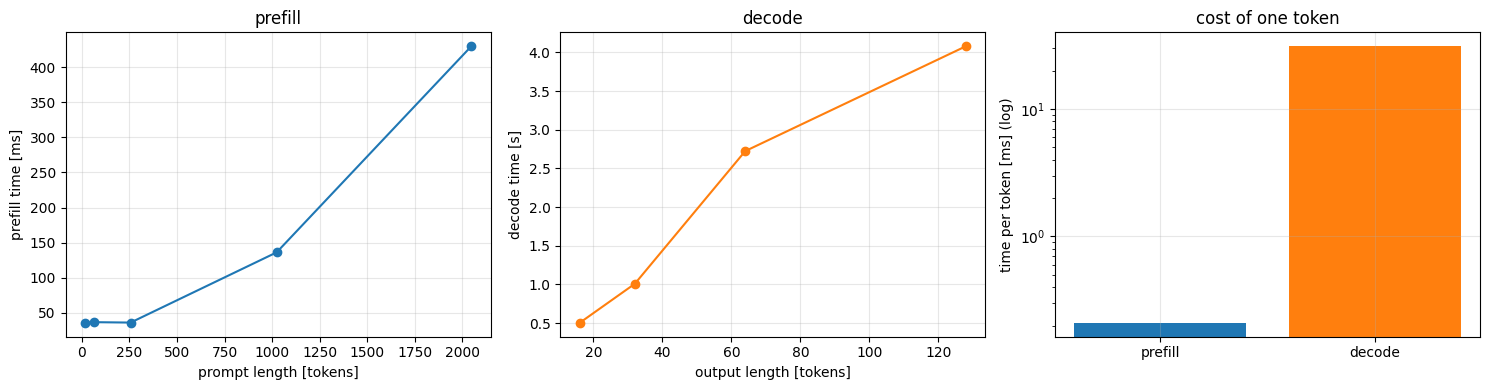

1トークンあたり: prefill 0.210 ms, decode 31.1 ms (148倍)


In [11]:
# 出力長を変えて decode の時間を測り、prefill と並べて図にする
OUT_LENS = [16, 32, 64, 128]
ids = build_ids("Write a long essay about the history of computers.")
decode_s, step_ms = [], None
for n in OUT_LENS:
    r = greedy_decode(small, ids, max_new=n, stop_at_eos=False)
    decode_s.append(sum(r["step_times"]))
    step_ms = np.array(r["step_times"]) * 1e3
    print("output %4d tokens: decode %6.2f s (%.1f ms/token)" % (n, decode_s[-1], decode_s[-1] / n * 1e3))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(PROMPT_LENS, prefill_ms, "o-")
ax[0].set_xlabel("prompt length [tokens]"); ax[0].set_ylabel("prefill time [ms]"); ax[0].set_title("prefill")
ax[1].plot(OUT_LENS, decode_s, "o-", color="C1")
ax[1].set_xlabel("output length [tokens]"); ax[1].set_ylabel("decode time [s]"); ax[1].set_title("decode")
per_token = [prefill_ms[-1] / PROMPT_LENS[-1], float(np.median(step_ms))]
ax[2].bar(["prefill", "decode"], per_token, color=["C0", "C1"])
ax[2].set_yscale("log"); ax[2].set_ylabel("time per token [ms] (log)"); ax[2].set_title("cost of one token")
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("1トークンあたり: prefill %.3f ms, decode %.1f ms (%.0f倍)" % (
    per_token[0], per_token[1], per_token[1] / per_token[0]))

## 結果の読み方

- **decodeの時間は出力長にほぼ比例する**
    - 1ステップの時間はほぼ一定で、それを出力トークン数だけ繰り返すためである
- **prefillは、プロンプトが短いうちはほとんど増えない**
    - GPUは多数のトークンを並列に計算できるので、短い入力ではGPUの計算能力が余っている
    - プロンプトが長くなると計算量そのものが効き始め、時間が伸びていく
- **1トークンあたりの時間は、prefillのほうが桁違いに短い**
    - 入力トークンは一度にまとめて処理できるが、出力トークンは前のトークンが決まらないと次を計算できない

律速（何が時間を決めているか）を整理する

| 段階 | 処理の形 | 律速 | 効く対策 |
| --- | --- | --- | --- |
| prefill | 多数のトークンを1回で並列処理 | 計算量（プロンプト長） | プロンプトを短くする、先頭を共有してキャッシュする（7節） |
| decode | 1トークンずつ逐次処理 | ステップ数（出力長）と1ステップの固定費 | 出力を短くする、バッチ処理で1ステップに複数の要求を相乗りさせる（4節） |

decodeの1ステップでは、たった1トークンのために全層の重みを読み出す
このときGPUの計算能力は大きく余っている
**余っている能力に他の要求を相乗りさせる**のが、次の節のバッチ処理である

APIの料金が入力トークンより出力トークンのほうで高く設定されることが多いのは、この非対称性の表れである

---

# 4. 同時実行とバッチ処理

ここまでは要求を1件ずつ送っていた
実際のサービスでは、複数の利用者が同時に要求を送ってくる

GPUは、同じ演算を多数のデータにまとめて適用するのが得意である
学習でミニバッチを使うのと同じ理由で、推論でも複数の要求を**1回の順伝播にまとめる**と効率が上がる

## バッチにすると1ステップの時間はどう変わるか

サーバを通す前に、モデル単体で確かめる
同じプロンプトを $B$ 個並べてバッチにし、decodeの1ステップにかかる時間を測る

- もしGPUに余力がなければ、1ステップの時間は $B$ 倍になり、毎秒トークン数は変わらない
- 余力があれば、1ステップの時間はあまり増えず、毎秒トークン数が $B$ 倍近くになる

batch  1:   30.6 ms/step,    32.7 tokens/s in total
batch  2:   32.1 ms/step,    62.2 tokens/s in total
batch  4:   32.0 ms/step,   125.2 tokens/s in total
batch  8:   32.1 ms/step,   248.9 tokens/s in total
batch 16:   42.1 ms/step,   379.9 tokens/s in total
batch 32:   47.3 ms/step,   677.1 tokens/s in total


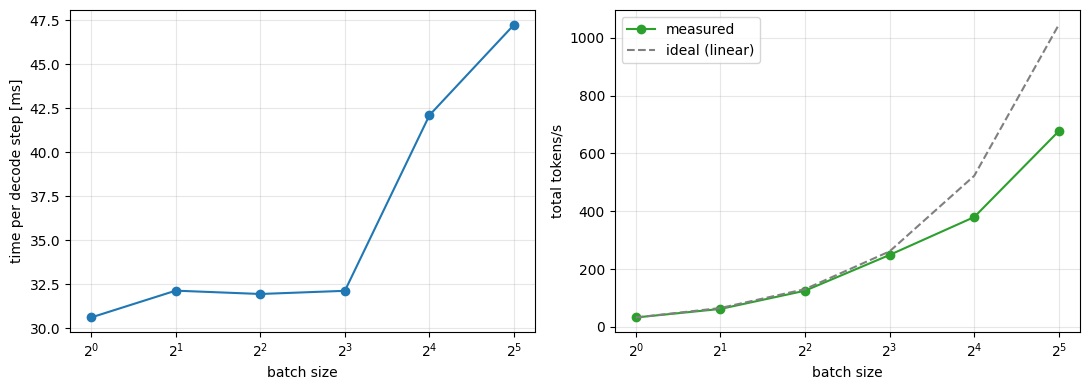

In [12]:
# バッチサイズを変えて、decode 1ステップの時間と毎秒トークン数を測る
BATCH_SIZES = [1, 2, 4, 8, 16, 32]
ids = build_ids("Write a long essay about the history of computers.")
bs_step_ms, bs_tps = [], []
greedy_decode(small, ids.repeat(2, 1), max_new=8, stop_at_eos=False)     # ウォームアップ
for b in BATCH_SIZES:
    r = greedy_decode(small, ids.repeat(b, 1), max_new=32, stop_at_eos=False)
    step = float(np.median(r["step_times"]))
    bs_step_ms.append(step * 1e3); bs_tps.append(b / step)
    print("batch %2d: %6.1f ms/step, %7.1f tokens/s in total" % (b, step * 1e3, b / step))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(BATCH_SIZES, bs_step_ms, "o-")
ax[0].set_xlabel("batch size"); ax[0].set_ylabel("time per decode step [ms]")
ax[1].plot(BATCH_SIZES, bs_tps, "o-", color="C2", label="measured")
ax[1].plot(BATCH_SIZES, [bs_tps[0] * b for b in BATCH_SIZES], "--", color="gray", label="ideal (linear)")
ax[1].set_xlabel("batch size"); ax[1].set_ylabel("total tokens/s"); ax[1].legend()
for a in ax:
    a.set_xscale("log", base=2); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 結果の読み方

- バッチサイズを32倍にしても、1ステップの時間はほとんど変わらない
    - 著者の環境（研究室のGPUサーバ、RTX PRO 6000、他の利用者がいない状態）で3回測ったところ、3回とも、バッチサイズ1で4.7ミリ秒、32で4.8ミリ秒であった
- その結果、全体の毎秒トークン数はバッチサイズにほぼ比例して増える（同じ測定で、バッチサイズ32のとき、1のときの約31倍）

小さいモデルで1トークンずつ生成しているとき、1ステップの時間の大半は、層ごとの関数呼び出しやGPUへの命令の発行といった**固定費**である
この固定費はバッチサイズによらないので、相乗りさせるほど1トークンあたりの費用が下がる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-batch-capacity.png" width=680>

上の図は、decodeの1ステップの時間の内訳を模式的に示したものである
バッチサイズ1では余っていた計算能力を、バッチサイズ8では他の要求の計算が埋めている

ただし、いつまでも比例するわけではない

- バッチが大きくなると、GPUの計算能力やメモリ帯域が先に尽き、1ステップの時間が伸び始める
- KVキャッシュは要求ごとに必要なので、GPUメモリの上限でもバッチサイズが決まる
- 大きいモデルほど1ステップの計算が重く、小さいバッチで頭打ちになる

どこで頭打ちになるかは、モデルとGPUの組み合わせで決まる
だから測る

## 負荷試験を自作する

次に、サーバに同時に要求を送って測る
負荷のかけ方には2種類ある

- **閉ループ**（closed loop）: $C$ 人の利用者がいて、それぞれが「応答を受け取ったら次の要求を送る」を繰り返す
    - 同時に処理中の要求数が常に $C$ になる
        - 実装が簡単で、サーバの最大能力を調べやすい
- **開ループ**（open loop）: 応答を待たず、決めた到着率（毎秒何件）で要求を送り続ける
    - 実際の利用者の振る舞いに近い
        - サーバが処理しきれないと待ち行列が伸び続ける様子が見える

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-closed-open-loop.png" width=680>

上の図は、2つの負荷のかけ方の違いを示している

ここでは閉ループを実装する
$C$ 本のスレッドがそれぞれ `stream_chat` を呼び続け、全体の所要時間から毎秒トークン数を求める
開ループは課題とする

各要求の所要時間の中身も記録しておくので、3節と同じ指標がそのまま得られる

In [13]:
# 同時リクエスト数を指定して負荷をかける関数を定義する（閉ループ）
def load_test(port, concurrency, n_requests, max_tokens=48, model=SMALL_NAME):
    """concurrency 本のスレッドで合計 n_requests 件を送り、指標を集計する"""
    def one(i):
        try:
            return stream_chat(PROMPTS[i % len(PROMPTS)], max_tokens, port, model=model)
        except requests.RequestException:
            return {"status": 0}                       # 接続失敗やタイムアウト
    t0 = time.perf_counter()
    with ThreadPoolExecutor(concurrency) as ex:
        rs = list(ex.map(one, range(n_requests)))
    wall = time.perf_counter() - t0
    ok = [r for r in rs if r["status"] == 200]
    return {"concurrency": concurrency,
            "rps": len(ok) / wall,
            "tok_s": sum(r["n_tokens"] for r in ok) / wall,
            "ttft_p50": pct([r["ttft"] for r in ok], 50), "ttft_p95": pct([r["ttft"] for r in ok], 95),
            "lat_p50": pct([r["latency"] for r in ok], 50), "lat_p95": pct([r["latency"] for r in ok], 95),
            "error_rate": 1 - len(ok) / n_requests}

def sweep(port, levels, model=SMALL_NAME):
    """同時リクエスト数を変えながら負荷試験を繰り返す"""
    load_test(port, 2, 4, model=model)                 # ウォームアップ
    rows = []
    print("%5s %8s %9s %10s %10s %9s %9s" % ("conc", "req/s", "tok/s", "TTFT p50", "TTFT p95", "lat p50", "lat p95"))
    for c in levels:
        r = load_test(port, c, n_requests=max(16, 4 * c), model=model)
        rows.append(r)
        print("%5d %8.2f %9.1f %9.0fms %9.0fms %8.2fs %8.2fs" % (
            c, r["rps"], r["tok_s"], r["ttft_p50"] * 1e3, r["ttft_p95"] * 1e3, r["lat_p50"], r["lat_p95"]))
    return rows

LEVELS = [1, 2, 4, 8, 16]
print("逐次処理（MAX_BATCH=1）")
res_serial = sweep(PORT_A, LEVELS)

逐次処理（MAX_BATCH=1）
 conc    req/s     tok/s   TTFT p50   TTFT p95   lat p50   lat p95
    1     0.58      27.6        39ms        49ms     1.54s     2.37s
    2     0.64      30.8      1528ms      2024ms     2.98s     3.60s
    4     0.64      30.6      4458ms      5271ms     6.01s     6.71s
    8     0.58      27.6     11100ms     16151ms    12.57s    17.80s
   16     0.65      31.1     23220ms     23483ms    24.70s    24.93s


## 結果の読み方（逐次処理）

- 同時リクエスト数を増やしても、**全体の毎秒トークン数は増えない**（受付の処理が増える分、むしろ下がることもある）
    - GPUを使う作業スレッドが1件ずつ処理しているので、処理能力は1件のときと同じである
- 一方で、**遅延は同時リクエスト数にほぼ比例して伸びる**
    - 後から来た要求は、前の要求の生成が終わるまで待ち行列で待つ
- 特にTTFTが大きく悪化する
    - 自分の番が来るまで最初の1文字も出ないためである

待ち行列が詰まったサーバでは、ストリーミングにしていても体感は改善しない

## 動的バッチ

3節の終わりで見たように、decodeの1ステップにはGPUの余力がある
そこで、待ち行列にたまった要求を**まとめて1つのバッチとして**生成する

これを**動的バッチ**（dynamic batching）と呼ぶ
学習のバッチと違い、何件まとまるかは到着の仕方で決まるので「動的」である

`serve_app.py` の `worker` は、すでにこの仕組みを持っている

- 最初の1件を取り出したあと、最大 `BATCH_WAIT_MS` ミリ秒だけ仲間を待つ
- `MAX_BATCH` 件に達するか、待ち時間が切れたら、集まった分で生成を始める

設定値は綱引きになる

- `BATCH_WAIT_MS` を長くすると、バッチが大きくなりスループットが上がるが、暇なときでもその分だけTTFTが増える
- `MAX_BATCH` を大きくすると、1ステップが重くなりITLが増え、GPUメモリの使用量も増える

長さの違うプロンプトを1つのテンソルにまとめるため、短いほうの左側を詰め物（padding）で埋め、`attention_mask` で無視させている

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-dynamic-batching.png" width=700>

上の図は、長さの違う3件の要求を1つのバッチにまとめる様子である

サーバを `MAX_BATCH=8`、`BATCH_WAIT_MS=30` で起動し直し、同じ負荷試験を行う

In [14]:
# 動的バッチ（MAX_BATCH=8）で起動し直し、同じ負荷試験を行う
BATCH_LOG = "batch_log.jsonl"
if os.path.exists(BATCH_LOG):
    os.remove(BATCH_LOG)
print(start_server(PORT_A, MAX_BATCH=8, BATCH_WAIT_MS=30, LOG_PATH=BATCH_LOG))
print("動的バッチ（MAX_BATCH=8）")
res_batch = sweep(PORT_A, LEVELS)

# サーバのログから、実際に何件ずつまとめて処理されたかを数える
sizes = [json.loads(line)["batch_size"] for line in open(BATCH_LOG)]
print("\nbatch size : number of requests")
for b in sorted(set(sizes)):
    print("%10d : %d" % (b, sizes.count(b)))

{'status': 'ok', 'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'version': 'v1', 'max_batch': 8, 'queue_depth': 0}
動的バッチ（MAX_BATCH=8）
 conc    req/s     tok/s   TTFT p50   TTFT p95   lat p50   lat p95
    1     0.61      29.3        69ms        77ms     1.55s     2.01s
    2     1.27      61.1        67ms        88ms     1.54s     1.77s
    4     2.62     125.6        67ms        74ms     1.51s     1.63s
    8     4.57     219.3        55ms        66ms     1.70s     2.06s
   16     4.97     238.8      1571ms      2048ms     3.05s     3.82s

batch size : number of requests
         1 : 16
         2 : 20
         4 : 16
         8 : 96


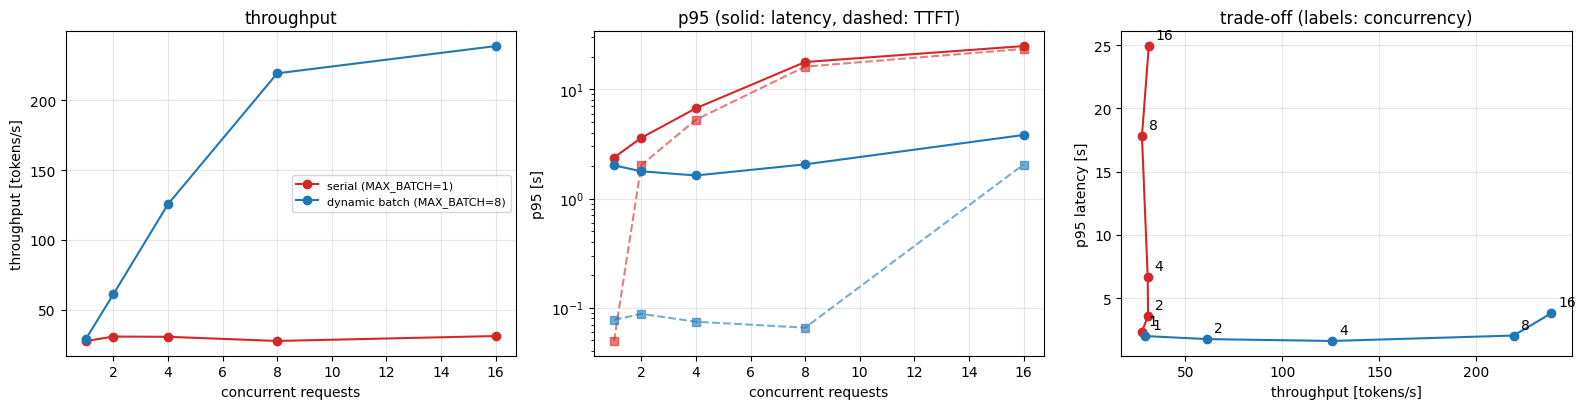

In [15]:
# 逐次処理と動的バッチを比べ、スループットと遅延のトレードオフ曲線を描く
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
for res, name, c in [(res_serial, "serial (MAX_BATCH=1)", "C3"), (res_batch, "dynamic batch (MAX_BATCH=8)", "C0")]:
    conc = [r["concurrency"] for r in res]
    ax[0].plot(conc, [r["tok_s"] for r in res], "o-", color=c, label=name)
    ax[1].plot(conc, [r["lat_p95"] for r in res], "o-", color=c, label=name + " latency")
    ax[1].plot(conc, [r["ttft_p95"] for r in res], "s--", color=c, alpha=0.6, label=name + " TTFT")
    ax[2].plot([r["tok_s"] for r in res], [r["lat_p95"] for r in res], "o-", color=c, label=name)
    for r in res:
        ax[2].annotate(str(r["concurrency"]), (r["tok_s"], r["lat_p95"]), textcoords="offset points", xytext=(5, 5))
ax[0].set_xlabel("concurrent requests"); ax[0].set_ylabel("throughput [tokens/s]"); ax[0].set_title("throughput")
ax[1].set_xlabel("concurrent requests"); ax[1].set_ylabel("p95 [s]"); ax[1].set_title("p95 (solid: latency, dashed: TTFT)")
ax[1].set_yscale("log")
ax[2].set_xlabel("throughput [tokens/s]"); ax[2].set_ylabel("p95 latency [s]")
ax[2].set_title("trade-off (labels: concurrency)")
for a in ax:
    a.grid(alpha=0.3)
ax[0].legend(fontsize=8, loc="center right")       # 色の意味は3つの図で共通
plt.tight_layout(); plt.show()

## 結果の読み方（動的バッチ）

- 動的バッチでは、同時リクエスト数が `MAX_BATCH` に達するまで、**スループットが伸び続ける**
    - 1ステップの時間はあまり変わらないまま、1ステップで進むトークン数が増えるためである
- その間、遅延はほとんど悪化しない
    - 逐次処理との差は同時リクエスト数が多いほど大きい
- 同時リクエスト数が `MAX_BATCH` を超えると、スループットの伸びは鈍るか止まり、あふれた要求が次のバッチを待つ分だけ遅延（特にTTFT）が伸びる
- 同時リクエスト数が1のときは、逐次処理より**少し遅い**
    - 仲間を待つ `BATCH_WAIT_MS` の分だけ、TTFTが伸びるためである
        - 暇なときには、待つだけ損になる
- ログの `batch_size` を見ると、同時リクエスト数に近い大きさのバッチが実際に組まれていることが分かる
    - `BATCH_WAIT_MS` を短くしすぎると、わずかに遅れて届いた要求が仲間に入れず、小さいバッチに分かれてしまう
    - 入れなかった要求は、前のバッチの生成が終わるまで丸ごと待たされる
- サーバ越しのスループットは、先ほどモデル単体で測った値より低い
    - HTTPの処理、トークンの復号、ストリーミングの送信といった、生成以外の仕事が加わるためである

右の図がトレードオフ曲線である

- 曲線の右下ほど良い（スループットが高く、遅延が小さい）
- 曲線が上に折れ曲がる点が、その設定での**処理能力の限界**である
- SLOが「p95遅延を何秒以内」と決まっていれば、その横線と曲線の交点が、**SLOを守れる最大のスループット**になる

10節の原価計算では、このスループットを使う
最大値ではなく「SLOを守れる範囲での値」を使うのが要点である

なお、バッチ処理では浮動小数点の計算順序が変わるため、同じプロンプトでも単独で処理したときと出力がわずかに変わることがある

## 連続バッチ

動的バッチには弱点がある
バッチを組んだら、**全員の生成が終わるまで次の要求を入れられない**

LLMの出力長は要求ごとに大きく違う
8件のバッチのうち7件が20トークンで終わり、1件だけが200トークン続くと、残りの180ステップは8席のうち1席しか使われない
その間、待ち行列の要求は空いた席を横目に待たされる

**連続バッチ**（continuous batching）は、これを1ステップ単位で解決する

- decodeの1ステップごとに、終わった要求をバッチから外す
- 空いた席に、待ち行列の要求をその場で入れる（新しい要求のprefillを行い、KVキャッシュを既存のバッチに合流させる）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-continuous-batching.png" width=760>

上の図は、席が4つ、要求が10件の例で、2つの方式の席の使われ方を比べたものである（このあとのコードで同じ例を計算して描く）
固定のバッチ（上段）では、長い要求1が終わるまで斜線の席が空かず、要求4〜9が待たされる
連続バッチ（下段）では、要求0、2、3が終わった席に、すぐ次の要求が入る

本テキストの自作サーバは動的バッチまでしか実装していない
連続バッチは、KVキャッシュを要求ごとに出し入れする管理が必要で、ここが専用の推論エンジンの中核である（5節）

効果の大きさは、簡単なシミュレーションで確かめられる
時間の単位をdecodeの1ステップとし、次の単純化を置く

- 1ステップの時間は、バッチ内の件数によらず一定とする（先ほどの実測で、小さいバッチではおおよそ成り立っていた）
- prefillの時間は無視する

まず、席が4つ、要求が10件の小さな例で、席がどう使われるかを図にする

static     latency of each request: [6, 25, 8, 5, 33, 28, 32, 24, 36, 31]  mean 22.8 steps
continuous latency of each request: [6, 25, 8, 5, 13, 9, 15, 11, 14, 13]  mean 11.9 steps


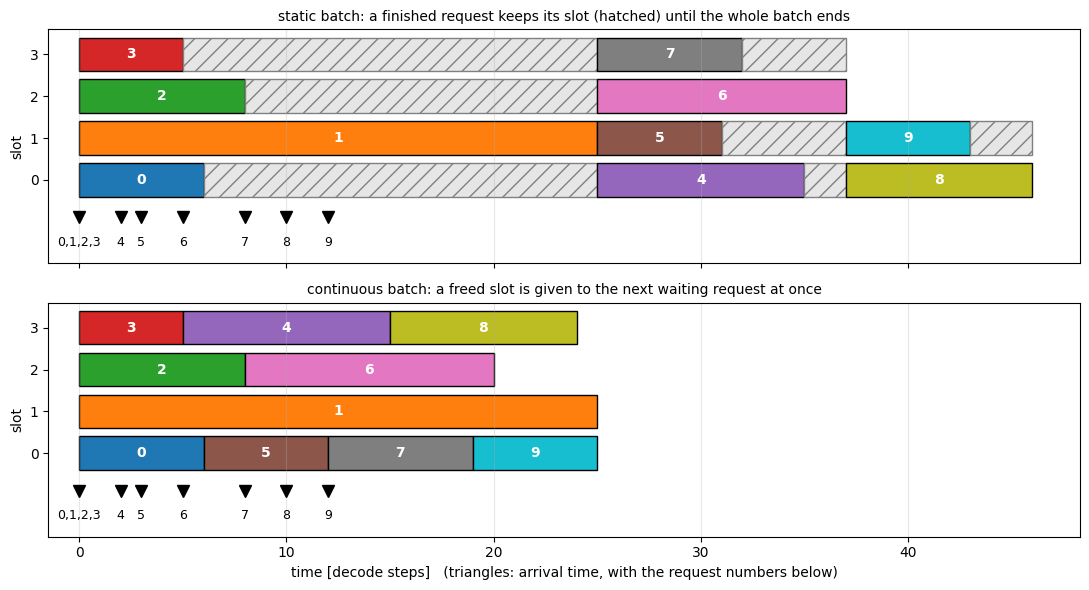

In [16]:
# 動的バッチ（組んだら全員が終わるまで固定）と連続バッチのシミュレータを書き、小さな例で席の使われ方を図にする
def simulate(policy, arrivals, lengths, slots=8, trace=None):
    """policy は "static" か "continuous"、時間の単位は decode 1ステップ、trace を渡すと (席, 要求, 着席, 終了) を記録する"""
    n, t, i = len(lengths), 0, 0
    waiting, seats = [], [None] * slots                         # seats[k] = [要求の番号, 残りトークン数, 着席時刻]
    latency, used = [None] * n, 0
    while any(x is None for x in latency):
        while i < n and arrivals[i] <= t:                       # 到着した要求を待ち行列へ
            waiting.append(i); i += 1
        if policy == "continuous" or all(s is None for s in seats):   # 席に入れてよいタイミングか
            for k in range(slots):
                if seats[k] is None and waiting:
                    j = waiting.pop(0); seats[k] = [j, lengths[j], t]
        if all(s is None for s in seats):                       # 誰もいなければ次の到着まで進める
            t = arrivals[i]; continue
        t += 1                                                  # decode 1ステップ
        for k, s in enumerate(seats):
            if s is None or s[1] == 0:
                continue
            s[1] -= 1; used += 1
            if s[1] == 0:
                latency[s[0]] = t - arrivals[s[0]]
                if trace is not None:
                    trace.append((k, s[0], s[2], t))
                if policy == "continuous":
                    seats[k] = None                             # 終わった席をすぐ空ける
        if policy == "static" and all(s is None or s[1] == 0 for s in seats):
            seats = [None] * slots                              # 全員が終わってから解散する
    return {"mean": np.mean(latency), "p95": pct(latency, 95), "tok_per_step": used / t, "latency": latency}

def draw_timeline(ax, trace, arrivals, title, hold):
    """席ごとの使われ方を横棒で描く、hold=True なら「終わったのに空かない席」を斜線で示す"""
    for k, j, t0, t1 in trace:
        ax.barh(k, t1 - t0, left=t0, color=plt.cm.tab10(j % 10), edgecolor="k")
        ax.text((t0 + t1) / 2, k, str(j), ha="center", va="center", color="w", fontsize=10, fontweight="bold")
        t_end = max(e for _, _, s0, e in trace if s0 == t0)     # 同じバッチの中で最も遅い終了
        if hold and t_end > t1:
            ax.barh(k, t_end - t1, left=t1, color="0.9", edgecolor="0.5", hatch="//")
    for a in sorted(set(arrivals)):                             # 到着時刻を下側に印で示す（同時に着いた要求はまとめて書く）
        ax.plot(a, -0.9, "v", color="k", markersize=8)
        ax.text(a, -1.5, ",".join(str(j) for j, x in enumerate(arrivals) if x == a), ha="center", va="center", fontsize=9)
    ax.set_yticks(range(4)); ax.set_ylim(-2.0, 3.6); ax.set_xlim(-1.5, None)
    ax.set_ylabel("slot"); ax.set_title(title, fontsize=10); ax.grid(alpha=0.3, axis="x")

# 小さな例: 席は4つ、要求は10件（番号は到着順）、要求1だけが長い
demo_arrivals = [0, 0, 0, 0, 2, 3, 5, 8, 10, 12]
demo_lengths = [6, 25, 8, 5, 10, 6, 12, 7, 9, 6]
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for a, policy, title in [(ax[0], "static", "static batch: a finished request keeps its slot (hatched) until the whole batch ends"),
                         (ax[1], "continuous", "continuous batch: a freed slot is given to the next waiting request at once")]:
    tr = []
    r = simulate(policy, demo_arrivals, demo_lengths, slots=4, trace=tr)
    draw_timeline(a, tr, demo_arrivals, title, hold=(policy == "static"))
    print("%-10s latency of each request: %s  mean %.1f steps" % (policy, r["latency"], r["mean"]))
ax[1].set_xlabel("time [decode steps]   (triangles: arrival time, with the request numbers below)")
plt.tight_layout(); plt.show()

## 図の読み方

横軸は時間（decodeのステップ数）、縦の4段が席、色つきの棒が要求である
棒の中の数字は要求の番号で、下の三角は到着した時刻を示す（三角の下の数字が、そのとき到着した要求の番号である）

**上の図（固定のバッチ）**

- 時刻0に到着した要求0〜3が、最初のバッチを組む
- 要求0、2、3は数ステップで終わるが、要求1だけが25ステップかかる
- 終わった3つの席は、要求1が終わるまで**空いているのに使えない**（斜線の部分）
- その間に到着した要求4〜9は、三角の位置から棒の左端まで、ずっと待たされている
    - 短い要求が、自分とは関係のない長い要求の完了を待たされる、という現象である

**下の図（連続バッチ）**

- 要求0、2、3が終わった席に、待っていた要求4、5、6がすぐに入る
- 要求1は同じ席で生成を続けており、他の要求を妨げない
- 斜線の部分が無く、どの要求も到着してから数ステップ待つだけで生成が始まる

全体が終わるまでの時間も、各要求の遅延も、連続バッチのほうが短い
1ステップの計算は同じなのに、**席の埋め方を変えただけ**でこの差が出る

この例は10件だけなので、次に2000件の要求で、負荷を変えながら統計を取る

    load |             static batch |         continuous batch
         |    mean     p95 tok/step |    mean     p95 tok/step
     0.2 |     138     341     1.56 |      61     184     1.56
     0.3 |     257     673     2.46 |      61     184     2.46
     0.5 |    6652   12308     2.90 |      63     185     4.17
     0.7 |   10179   19291     2.90 |      69     195     5.57
     0.9 |   12623   23618     2.91 |     108     251     7.14


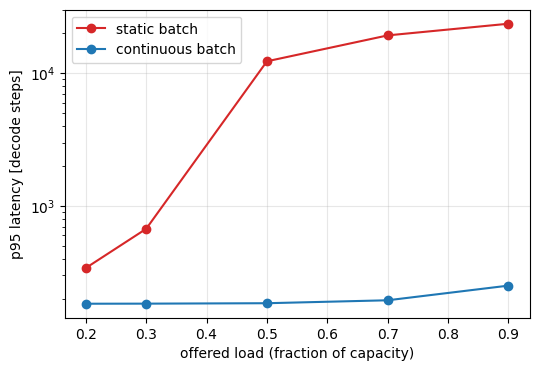

In [17]:
# 2000件の要求で、負荷を変えながら2つの方式の遅延を比べる
rng = np.random.default_rng(SEED)
N_SIM = 2000
lengths = np.clip(rng.exponential(60, N_SIM), 5, 400).astype(int)     # 出力長: 短いものが多く、時々長い
print("%8s | %24s | %24s" % ("load", "static batch", "continuous batch"))
print("%8s | %7s %7s %8s | %7s %7s %8s" % ("", "mean", "p95", "tok/step", "mean", "p95", "tok/step"))
sim = {"static": [], "continuous": []}
LOADS = [0.2, 0.3, 0.5, 0.7, 0.9]
for load in LOADS:
    # load は「8席が常に埋まる到着率」に対する割合
    rate = load * 8 / lengths.mean()
    arrivals = np.cumsum(rng.exponential(1 / rate, N_SIM))
    s, c = simulate("static", arrivals, lengths), simulate("continuous", arrivals, lengths)
    sim["static"].append(s); sim["continuous"].append(c)
    print("%8.1f | %7.0f %7.0f %8.2f | %7.0f %7.0f %8.2f" % (
        load, s["mean"], s["p95"], s["tok_per_step"], c["mean"], c["p95"], c["tok_per_step"]))

plt.figure(figsize=(6, 4))
for name, c in [("static", "C3"), ("continuous", "C0")]:
    plt.plot(LOADS, [r["p95"] for r in sim[name]], "o-", color=c, label=name + " batch")
plt.xlabel("offered load (fraction of capacity)"); plt.ylabel("p95 latency [decode steps]")
plt.yscale("log"); plt.grid(alpha=0.3); plt.legend(); plt.show()

## 結果の読み方

出力長は平均60トークンの指数分布（短いものが多く、時々長い）、到着はランダム（ポアソン到着）とした
`load` は、8席が常に埋まるときの処理能力に対する到着の割合である

- 負荷が軽いうちは、連続バッチの遅延はほぼ出力長そのものである
    - 固定のバッチは、負荷が軽くても遅延が大きい（前のバッチが解散するまで待つため）
- 負荷が上がると、固定のバッチでは遅延が急に伸びる
    - 長い要求が1件あるだけで、バッチ全体が解散できず、空いた席が使われないためである
    - `tok/step`（1ステップで進んだトークン数）が8席のうち3席分ほどで頭打ちになっている
        - これが固定のバッチの実質的な処理能力である
    - 到着がこれを超えると待ち行列が伸び続けるので、表の遅延はシミュレーションを長く続けるほど大きくなる
- 連続バッチでは、空いた席がすぐに埋まるので、同じ到着率でも遅延の伸びが緩やかである

この差は、出力長のばらつきが大きいほど広がる
全員が同じ長さを出力するなら、固定のバッチでも無駄は出ない
LLMの出力長は事前に分からず、ばらつきが大きいので、連続バッチが事実上の標準になっている

シミュレーションは単純化を含む
実際には、合流のたびにprefillが割り込むので、既存の要求のITLが一時的に伸びる

In [18]:
# 4節で使ったサーバを停止する（GPUメモリを解放する）
stop_all()
print("running servers:", list(servers))

running servers: []


---

# 5. 専用の推論エンジン

自作サーバは220行ほどで動いたが、実用には足りないものが多い
専用の推論エンジンは、主に次の問題を解決している

| 問題 | 自作サーバ | 専用エンジンの解決 |
| --- | --- | --- |
| 出力長のばらつきで席が無駄になる | 動的バッチ（全員が終わるまで固定） | 連続バッチ（1ステップ単位で入れ替え） |
| KVキャッシュのメモリ管理 | 要求ごとに最大長分を確保し、詰め物の分も無駄になる | ページ単位で割り当て、断片化と無駄を抑える（PagedAttention） |
| 同じ先頭を持つプロンプト | 毎回すべて計算する | 先頭のKVキャッシュを共有する（7節） |
| 1ステップの固定費 | Pythonのループと汎用の演算 | 最適化された演算、演算の融合、グラフのコンパイル |
| サンプリング、停止条件、構造化出力 | 貪欲法のみ | 各種のサンプリング設定、JSONなどの形式を強制する生成 |
| 複数GPU | 非対応 | テンソル並列などでモデルを分割 |

代表的なエンジンを挙げる（2026年時点）

- **vLLM**: PagedAttentionと連続バッチを中心とするエンジン
    - OpenAI互換のサーバを内蔵する
- **TensorRT-LLM**: NVIDIAのGPUに特化し、モデルを事前にコンパイルして最適化する
- **Text Generation Inference**（TGI）: Hugging Faceが提供するサーバ
- **llama.cpp**: CPUや個人のPCでの実行に強い
    - GGUF形式の量子化モデルを使う

PagedAttention、vLLM、TensorRT-LLMの仕組みは「LLM-1 Basics」と「NLP-6 GPT-full」の章を参照
ここでは、自作サーバと同じ負荷試験をかけて、**外から見た違い**を確かめる

## vLLMを起動して比べる（任意）

以下の2つのセルは**任意**である
既定では `RUN_VLLM = False` としてあり、そのまま実行しても何も起きない

任意とした理由を正直に書いておく

- vLLMは特定のバージョンのPyTorchに依存しており、Colabに最初から入っているPyTorchを入れ替えてしまう
    - そのため、ノートブックとは**別の仮想環境**に導入し、別プロセスとして起動する形にした（`uv` は「運用」の章を参照）
    - 仮想環境のPythonは3.12に固定している
- 導入には数GBのダウンロードが必要で、数分〜十数分かかる
    - 起動にも1〜2分かかる
- 著者は、研究室のGPUサーバ（Linux、単一GPU、他の利用者と共用）で、以下の2つのセルのとおりに導入、起動、負荷試験、停止まで動作することを確認した（vLLM 0.31.0、2026年10月）
    - その際、起動に失敗する原因が2つあったので、セルの中で対処してある
    - GPUメモリ: vLLMは既定でGPUメモリの9割を確保しようとし、ノートブック側のモデルがすでにメモリを使っていると起動できないので、使ってよい割合とKVキャッシュの量を明示した
    - サンプリング用の演算の実行時コンパイル: CUDAの開発環境（`nvcc`）が無いマシンでは失敗するので、環境変数で無効にした
- **ColabのT4では動作を確認していない**
    - vLLMが対応するGPUやPythonのバージョンは更新が速いので、失敗する場合は `vllm.out` に残るログと公式文書の導入手順を確認すること
    - 失敗しても、以降の節には影響しない

vLLMのサーバはOpenAI互換なので、自作サーバ用に書いた `stream_chat` と `load_test` が**そのまま使える**
2節で形をそろえた利点がここで効く

In [19]:
# このセルは任意（導入に数分かかる）: vLLM を専用の仮想環境に導入する
RUN_VLLM = False           # 試す場合は True にする
VLLM_ENV = "vllm-env"
PORT_V = 8002

if RUN_VLLM and not os.path.exists(f"{VLLM_ENV}/bin/vllm"):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
    subprocess.run([sys.executable, "-m", "uv", "venv", "-q", "--python", "3.12", VLLM_ENV], check=True)
    subprocess.run([sys.executable, "-m", "uv", "pip", "install", "-q",
                    "--python", f"{VLLM_ENV}/bin/python", "vllm"], check=True)
print("vLLM installed:", os.path.exists(f"{VLLM_ENV}/bin/vllm"))

vLLM installed: False


In [20]:
# このセルは任意: vLLM を起動し、自作サーバと同じ負荷試験をかけてから停止する
res_vllm = None
if RUN_VLLM:
    stop_server(PORT_V)
    # vLLM は既定でGPUメモリのほぼ全体を確保しようとするので、ノートブック側のモデルと共存できるように抑える
    # --gpu-memory-utilization: 使ってよいGPUメモリの割合（起動時の空きがこれより少ないと失敗する）
    # --kv-cache-memory-bytes: KVキャッシュ用に確保する量
    proc = subprocess.Popen(
        [f"{VLLM_ENV}/bin/vllm", "serve", SMALL_NAME, "--host", "127.0.0.1", "--port", str(PORT_V),
         "--dtype", "half", "--max-model-len", "2048",
         "--gpu-memory-utilization", "0.5", "--kv-cache-memory-bytes", str(2 * 1024 ** 3)],
        # VLLM_USE_FLASHINFER_SAMPLER=0: CUDAの開発環境（nvcc）が無いマシンでも起動できるようにする
        env=dict(os.environ, VLLM_USE_FLASHINFER_SAMPLER="0"),
        stdout=open("vllm.out", "w"), stderr=subprocess.STDOUT)
    servers[PORT_V] = proc
    try:
        wait_ready(proc, PORT_V, "vllm.out", limit=900)
        r = stream_chat("機械学習における過学習とは何かを説明してください", max_tokens=48, port=PORT_V)
        print(r["text"], "\n")
        print("vLLM")
        res_vllm = sweep(PORT_V, LEVELS + [32])
    finally:
        stop_server(PORT_V)

    plt.figure(figsize=(6, 4))
    for res, name, c in [(res_serial, "ours: serial", "C3"), (res_batch, "ours: dynamic batch", "C0"),
                         (res_vllm, "vLLM", "C2")]:
        plt.plot([r["concurrency"] for r in res], [r["tok_s"] for r in res], "o-", color=c, label=name)
    plt.xlabel("concurrent requests"); plt.ylabel("throughput [tokens/s]")
    plt.xscale("log", base=2); plt.grid(alpha=0.3); plt.legend(); plt.show()

## 結果の読み方（著者の環境での観察）

著者の環境（研究室のGPUサーバ、RTX PRO 6000、他の利用者がいない状態）で `RUN_VLLM = True` として実行したときの結果を記す（vLLM 0.31.0、同じ実行の中で自作サーバと比べた値）

| 同時リクエスト数 | 自作（逐次） | 自作（動的バッチ） | vLLM |
| --- | --- | --- | --- |
| 1 | 205 | 180 | 636 |
| 8 | 206 | 1303 | 3995 |
| 16 | 206 | 1312 | 7461 |
| 32 | （未測定） | （未測定） | 13912 |

単位は毎秒トークン数である

- vLLMのスループットは、同時リクエスト数を32まで増やしても、ほぼ比例して伸び続けた
    - 自作サーバは `MAX_BATCH=8` で頭打ちになるが、vLLMはKVキャッシュのメモリが許す限り、到着した要求を走行中のバッチに合流させる
    - 同時32件のときのスループットは、自作サーバ（動的バッチ）の最大値の約11倍であった
- TTFTの中央値は、同時リクエスト数が1から32のあいだで6〜12ミリ秒に収まった
    - 自作サーバでは、同時リクエスト数が `MAX_BATCH` を超えると、TTFTが前のバッチの生成時間の分（約300ミリ秒）だけ伸びた
    - 連続バッチでは空いた席を待つ必要がないためである
- 同時1件のときの速さも、自作サーバ（逐次）の約3倍であった
    - 1ステップあたりの固定費（Pythonのループ、汎用の演算）が削られているためである

起動には、自作サーバ（約4秒）より長い時間がかかった（モデルの読み込みに加えて、実行グラフの準備などを行うためである）
導入の手間と起動時間を払う代わりに、高い負荷での処理能力を得る、という関係にある

自作サーバの値は3回の測定で1%程度しか変わらなかったが、vLLMの測定は1回だけである
また、GPUを他の利用者が使っている時間帯に測ったときは、どちらのスループットも半分前後かそれ以下に下がり、vLLMのTTFTのp95が1秒を超える回もあった
共用のGPUでの測定値は、その時の混み具合を測っているにすぎないことがある

なお、vLLMは既定でサンプリングを行うので、出力の文面は貪欲法の自作サーバとは一致しない
ここで比べているのは速さだけである

---

# 6. 量子化して提供する

量子化（quantization）は、重みを少ないビット数で表してモデルを小さくする技術である
仕組みと各手法（GPTQ、AWQ、GGUFなど）は「LLM-1 Basics」と「NLP-6 GPT-full」の章を参照

提供する側にとって、量子化の動機は主にメモリである

- GPUメモリに収まらないモデルは、そもそも提供できない
- 同じGPUに、より大きいモデルを載せられる
    - あるいは、KVキャッシュに回せるメモリが増え、同時に処理できる要求が増える

一方、「量子化すれば速くなる」とは限らない
速度は、量子化された重みをGPUがどう計算するか、つまり**実装**に依存する

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-quantization-tradeoff.png" width=680>

上の図は、量子化で動く3つの量の関係を整理したものである
メモリは確実に減るが、品質と速度は測ってみなければ分からない

ここでは `bitsandbytes` を使い、大きいほうのモデル（1.5B）を3通りに読み込んで比べる

| 設定 | 重みの表現 |
| --- | --- |
| fp16 | 16bit浮動小数点（基準） |
| 8bit | 8bit整数 |
| 4bit | 4bit（NF4） |

測るのは3つである

- **メモリ**: 重みが占めるサイズ
- **速度**: prefillの時間とdecodeの毎秒トークン数
- **品質**: 次の2つの指標で見る
    - パープレキシティ（perplexity）: 文章の次のトークンをどれだけ正しく予測できるか
        - 小さいほど良い
    - fp16との一致率: 各位置で最も確率の高いトークンが、fp16のモデルと同じである割合

In [21]:
# 品質を測るための文章と、評価の関数を用意する
EVAL_TEXT = """Machine learning systems are built in two phases. In the training phase, a model learns
its parameters from a large dataset, and the goal is to minimize a loss function as quickly as possible.
In the serving phase, the trained model answers requests from users, and the goal changes completely.
Each user cares about how long they wait, not about the average speed of the whole system.
A service that is fast on average but occasionally very slow feels unreliable.
Engineers therefore measure the distribution of latency and pay attention to its tail.
They also watch the cost of each request, because a graphics processing unit is expensive
and it must be shared among many users. Batching several requests together improves efficiency,
but each request may wait longer for the others to arrive. Reducing the precision of the weights
saves memory, but it may change the answers of the model. Caching avoids repeated work,
but it only helps when requests resemble each other. Good serving is the art of balancing these
forces while keeping a promise to the user about speed, quality, and availability."""
eval_ids = tok(EVAL_TEXT, return_tensors="pt").input_ids.to(device)
print("evaluation text:", eval_ids.shape[1], "tokens")

@torch.inference_mode()
def score_text(model, ids):
    """パープレキシティと、各位置で最も確率の高いトークンを返す"""
    logits = model(input_ids=ids).logits[0, :-1].float()
    loss = torch.nn.functional.cross_entropy(logits, ids[0, 1:])
    return math.exp(loss.item()), logits.argmax(-1).cpu()

def free():
    """参照が無くなったモデルのGPUメモリを解放する（先に del でモデルへの参照を消しておく）"""
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()

evaluation text: 215 tokens


In [22]:
# fp16、8bit、4bit の順に読み込み、メモリ、速度、品質を測る
QUANTS = [None, "8bit", "4bit"] if device.type == "cuda" else [None]   # 量子化はGPUが必要
gen_ids = build_ids("Explain why the sky is blue in two sentences.")
quant_rows, ref_top1 = [], None
for q in QUANTS:
    m = load_model(LARGE_NAME, q)
    greedy_decode(m, gen_ids, max_new=4)                                  # ウォームアップ
    r = greedy_decode(m, gen_ids, max_new=48, stop_at_eos=False)
    t_pre = np.median([greedy_decode(m, filler[:, :512], max_new=1, stop_at_eos=False)["t_prefill"] for _ in range(3)])
    ppl, top1 = score_text(m, eval_ids)
    ref_top1 = top1 if ref_top1 is None else ref_top1
    quant_rows.append({"name": q or "fp16",
                       "mem_gb": m.get_memory_footprint() / 1e9,
                       "tps": 1 / np.median(r["step_times"]),
                       "prefill_ms": t_pre * 1e3,
                       "ppl": ppl,
                       "agree": (top1 == ref_top1).float().mean().item(),
                       "text": tok.decode(r["tokens"], skip_special_tokens=True)})
    del m; free()

print("%-6s %10s %12s %14s %8s %10s" % ("", "mem [GB]", "decode tok/s", "prefill512 ms", "ppl", "agree"))
for row in quant_rows:
    print("%-6s %10.2f %12.1f %14.1f %8.2f %9.1f%%" % (
        row["name"], row["mem_gb"], row["tps"], row["prefill_ms"], row["ppl"], row["agree"] * 100))
print()
for row in quant_rows:
    print("[%s] %s\n" % (row["name"], row["text"].replace("\n", " ")))

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

ストリーミング出力は最後の 5000 行に切り捨てられました。


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

         mem [GB] decode tok/s  prefill512 ms      ppl      agree
fp16         3.09         23.0          100.2    14.29     100.0%
8bit         1.78          2.0          622.3    14.39      96.3%
4bit         1.12         11.1          218.6    15.20      84.6%

[fp16] The sky appears blue because the Earth's atmosphere scatters sunlight in all directions, with shorter blue wavelengths being scattered more than longer red wavelengths. This scattering effect makes the sky appear blue during the day, while the sun is high in the sky

[8bit] The sky appears blue because the Earth's atmosphere scatters sunlight in all directions, with shorter blue wavelengths being scattered more than longer red wavelengths, creating the blue color we see. This effect is known as Rayleigh scattering. Human

[4bit] The sky appears blue because the Earth's atmosphere scatters sunlight in all directions, and blue light is scattered more than other colors due to its shorter wavelength. When sunlight enters t

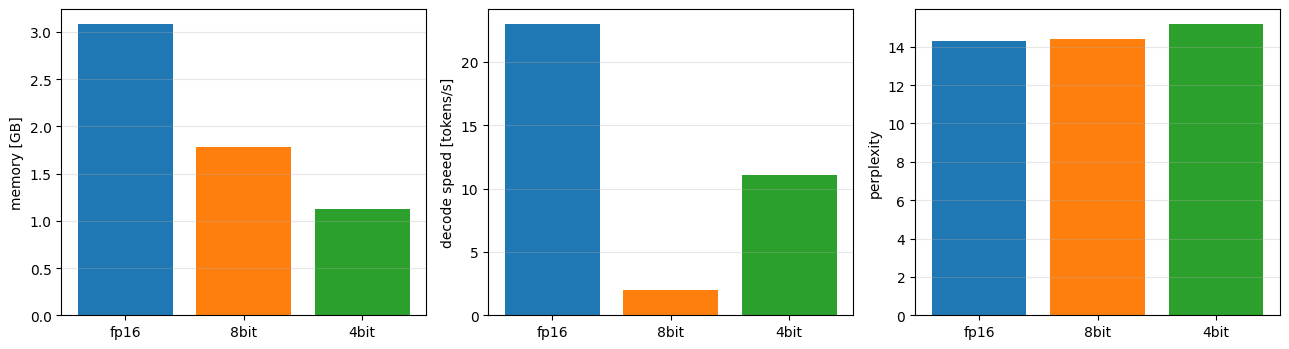

In [23]:
# 量子化の結果を図にする
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
names = [r["name"] for r in quant_rows]
for a, key, label in zip(ax, ["mem_gb", "tps", "ppl"], ["memory [GB]", "decode speed [tokens/s]", "perplexity"]):
    a.bar(names, [r[key] for r in quant_rows], color=["C0", "C1", "C2"][:len(names)])
    a.set_ylabel(label); a.grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 結果の読み方

**メモリ**

- 重みのサイズは、fp16、8bit、4bitの順に確実に小さくなる
- ただし、きれいに1/2、1/4にはならない
    - `bitsandbytes` が量子化するのは線形層の重みであり、埋め込み層などは元の精度のまま残るためである
    - 小さいモデルほど埋め込み層の占める割合が大きいので、削減率は控えめになる

**速度**

著者の環境（研究室のGPUサーバ、RTX PRO 6000、他の利用者がいない状態）で3回測った値を示す

| 設定 | decode [トークン/秒] | prefill（512トークン） [ミリ秒] |
| --- | --- | --- |
| fp16 | 177〜180 | 10.5 |
| 8bit | 15.5〜16.1 | 68〜71 |
| 4bit | 116〜118 | 13.4〜13.5 |

- **8bitは極端に遅くなる**（decodeがfp16の約11分の1）
    - `bitsandbytes` の8bitは、計算のたびに重みを変換する処理が入り、速度よりもメモリの削減を目的とした実装である
- **4bitもfp16より遅い**（decodeがfp16の約3分の2）
    - メモリは約3分の1になるが、速くはならない
    - 4bitの重みは、計算の直前に16bitへ展開されてから使われるので、展開の手間が増える分だけ遅くなる
- 「量子化 = 高速化」ではないことが分かる
    - 速度を目的とするなら、量子化された重みを直接計算できる専用のエンジンや形式（AWQやGPTQとvLLMの組み合わせ、GGUFとllama.cppなど）を選ぶ必要がある

**測定についての教訓**

- 上の値は、GPUを他の利用者が使っていない状態で測ったもので、3回の差は数%以内であった
- 同じコードを、他の利用者がGPUを使っている時間帯に実行したときは、値が2〜3倍ぶれ、fp16と4bitの速さの順序が入れ替わる回まであった
- 速度の測定は、**他の負荷が無い状態で、複数回**行う
    - 1回だけの測定や、混んでいるときの測定から「どちらが速い」と結論してはいけない
    - 自分の環境でも、このセルを3回実行して、値がどれだけ動くかを確かめてほしい

**品質**

- パープレキシティは、8bitではfp16とほとんど変わらず、4bitではわずかに悪化する
- fp16との一致率は、8bitで9割強、4bitで8割台に下がる
    - パープレキシティの変化は小さくても、「最も確率の高いトークン」は意外に入れ替わる
    - 生成は前のトークンに依存するので、1か所の入れ替わりで、その先の文面は別のものになる（上の出力例を見比べること）
- ただし、文面が変わることと、質が下がることは別である
    - 出力例はどれも質問に答えている

ここで使った評価文は200トークン程度で、品質を論じるには少なすぎる
実際には、自分のサービスの要求に近い評価データで、量子化の前後の正答率を比べる（8節の評価用の質問を使って試すとよい、評価データの設計は「LLM-4 評価」の章を参照）

提供する側の判断としては、次のように整理できる

- GPUメモリが足りないなら、4bitは有力な選択肢である
    - 品質の低下を自分の評価データで確かめたうえで使う
- メモリが足りているなら、fp16のままがよい（この実装では最も速く、品質も基準どおりである）
- どちらの場合も、速度は実装に依存するので測る

---

# 7. キャッシュ

もっとも速い計算は、計算しないことである
LLMの提供では、3つの階層でキャッシュが使える

| 階層 | 何を取っておくか | 効く場面 |
| --- | --- | --- |
| KVキャッシュ | 1つの要求の中で、過去のトークンの計算結果 | すべての生成（常に有効にする） |
| 応答キャッシュ | 要求全体に対する応答 | まったく同じ要求が繰り返される場合 |
| プロンプト先頭の共有 | 複数の要求に共通する先頭部分のKVキャッシュ | 同じシステムプロンプトや文書を何度も使う場合 |

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-cache-layers.png" width=720>

上の図は、1件の要求が3つの階層を順に通る様子である
左で当たるほど、省ける計算が大きい

## KVキャッシュの効果を測る

KVキャッシュは、ここまでの生成で当然のように使ってきた（`use_cache=True`）
その効果を知るために、あえて無効にして比べる

キャッシュが無いと、1トークンを生成するたびに**それまでの全トークンを最初から計算し直す**

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-kv-cache.png" width=700>

上の図の1行が生成の1ステップである
キャッシュが無いと行が伸びるたびに全部を計算し直すが、キャッシュがあれば右端の1個だけを計算すればよい
仕組みは「LLM-1 Basics」の章を参照

output   16 tokens: with cache   0.88 s, without   2.39 s (2.7x)
output   32 tokens: with cache   1.79 s, without   4.79 s (2.7x)
output   64 tokens: with cache   3.17 s, without   9.84 s (3.1x)
output  128 tokens: with cache   6.19 s, without  20.90 s (3.4x)


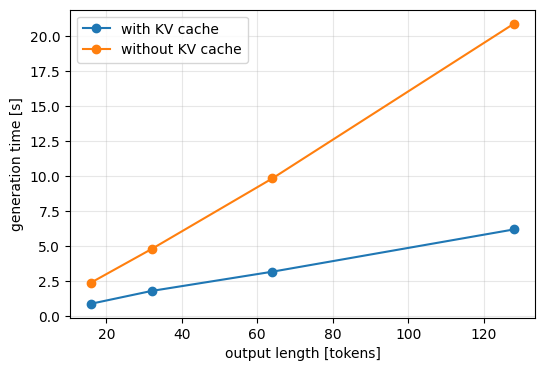

In [24]:
# KVキャッシュの有無で、生成時間がどう変わるかを測る
def timed_generate(model, ids, n, use_cache):
    sync(); t0 = time.perf_counter()
    with torch.inference_mode():
        model.generate(ids, attention_mask=torch.ones_like(ids), do_sample=False, use_cache=use_cache,
                       max_new_tokens=n, min_new_tokens=n, pad_token_id=tok.eos_token_id)
    sync()
    return time.perf_counter() - t0

kv_ids = filler[:, :1024]                      # 1024トークンのプロンプトに続けて生成する
KV_LENS = [16, 32, 64, 128]
timed_generate(small, kv_ids, 4, True); timed_generate(small, kv_ids, 4, False)   # ウォームアップ
t_on = [timed_generate(small, kv_ids, n, True) for n in KV_LENS]
t_off = [timed_generate(small, kv_ids, n, False) for n in KV_LENS]
for n, a, b in zip(KV_LENS, t_on, t_off):
    print("output %4d tokens: with cache %6.2f s, without %6.2f s (%.1fx)" % (n, a, b, b / a))

plt.figure(figsize=(6, 4))
plt.plot(KV_LENS, t_on, "o-", label="with KV cache")
plt.plot(KV_LENS, t_off, "o-", label="without KV cache")
plt.xlabel("output length [tokens]"); plt.ylabel("generation time [s]")
plt.grid(alpha=0.3); plt.legend(); plt.show()

## 結果の読み方

- KVキャッシュが無いと、生成時間が伸びる
    - 著者の環境（研究室のGPUサーバ、RTX PRO 6000、他の利用者がいない状態）では、3回とも、出力16トークンで約1.3倍、128トークンで約1.6倍であった
    - GPUが遅いほど、またプロンプトが長いほど、この倍率は大きくなる
- 差は出力が長いほど広がる
    - キャッシュがあれば、1ステップの計算量は新しい1トークン分でほぼ一定である
    - キャッシュが無ければ、1ステップごとにプロンプトとそれまでの出力の全体を計算し直すので、文脈が伸びるほど1ステップが重くなる
- 3節で見たとおり、短い入力ではGPUの並列処理に余力があるため、文脈が短いうちは差が小さい
    - プロンプトを1024トークンと長めにしたのはこのためである

KVキャッシュは無効にする理由がなく、常に使う
ただし、その代償としてGPUメモリを消費する
同時に処理する要求の数だけKVキャッシュが必要になり、これが4節で述べた「GPUメモリの上限でバッチサイズが決まる」ことの正体である

## 同一プロンプトのキャッシュ

「営業時間を教えて」のように、多くの利用者が**一字一句同じ要求**を送るサービスがある
その場合、応答そのものを保存しておけば、GPUを使わずに返せる

実装は辞書1つで足りる
要点は、**何をキーにするか**である

- 応答を変えうるものはすべてキーに含める: モデル名、`messages` の全体、`max_tokens`、サンプリングの設定
- 1つでも漏れると、別の設定で作られた応答を誤って返してしまう

以下では、キーをハッシュ値にして辞書に保存する
件数の上限を超えたら、最も長く使われていないものから捨てる（LRU、Least Recently Used）

In [25]:
# 応答キャッシュ: 同じ要求には、保存しておいた応答を返す
class ResponseCache:
    def __init__(self, capacity=1000):
        self.capacity, self.data, self.hits, self.misses = capacity, {}, 0, 0
    @staticmethod
    def key(model_name, messages, max_tokens):
        raw = json.dumps([model_name, messages, max_tokens], ensure_ascii=False, sort_keys=True)
        return hashlib.sha256(raw.encode()).hexdigest()
    def get_or_compute(self, model_name, messages, max_tokens, compute):
        k = self.key(model_name, messages, max_tokens)
        if k in self.data:
            self.hits += 1
            self.data[k] = self.data.pop(k)            # 最近使ったものを末尾へ移す
            return self.data[k]
        self.misses += 1
        self.data[k] = compute()
        if len(self.data) > self.capacity:
            self.data.pop(next(iter(self.data)))       # 先頭（最も長く使われていないもの）を捨てる
        return self.data[k]

def answer(question, max_tokens=32):
    return greedy_decode(small, build_ids(question), max_new=max_tokens)["text"]

cache = ResponseCache()
# 人気のある質問に要求が集中する状況を作る（少数の質問が何度も来る）
faq = ["What are your opening hours?", "How do I reset my password?", "Where is the nearest station?",
       "Do you ship overseas?", "How can I contact support?"]
rng = np.random.default_rng(SEED)
stream = [faq[i] for i in rng.choice(len(faq), size=40, p=[0.5, 0.2, 0.15, 0.1, 0.05])]

t0 = time.perf_counter()
for q in stream:
    answer(q)
t_plain = time.perf_counter() - t0

t0 = time.perf_counter()
for q in stream:
    msgs = [{"role": "user", "content": q}]
    cache.get_or_compute(SMALL_NAME, msgs, 32, lambda: answer(q))
t_cached = time.perf_counter() - t0

print("without cache: %.2f s" % t_plain)
print("with cache   : %.2f s (hits %d, misses %d, hit rate %.0f%%)" % (
    t_cached, cache.hits, cache.misses, 100 * cache.hits / len(stream)))

without cache: 53.61 s
with cache   : 7.05 s (hits 35, misses 5, hit rate 88%)


## 結果の読み方と注意点

- 40件のうち、実際に生成したのは質問の種類の数だけで、残りは辞書を引くだけで返せた
- 効果は**ヒット率**で決まる
    - 自由な対話のように同じ要求がほとんど来ないサービスでは、効果はない

応答キャッシュには落とし穴がある

- **サンプリングとの相性**: `temperature` が0より大きい設定では、本来は毎回違う応答が返る
    - キャッシュすると毎回同じ応答になる
- **鮮度**: モデルを更新したら、古いモデルの応答を返してはいけない
    - キーにモデルの版を含めるか、更新時にキャッシュを空にする
- **個人情報**: ある利用者への応答を、別の利用者に返してはいけない
    - 利用者に固有の情報が入る要求は、キャッシュの対象から外すか、利用者ごとにキーを分ける
- **表記のゆれ**: 「営業時間は？」と「営業時間を教えて」は別のキーになる
    - 意味の近い要求をまとめる「意味キャッシュ」（埋め込みベクトルの近さで判定する）もあるが、違う質問に同じ答えを返す危険が増える
    - 意味キャッシュの実装と、しきい値による誤ヒットの変化は、「LLM-2 Application」の章の「意味キャッシュ」を参照

## プロンプト先頭の共有

実際のサービスでは、要求の**先頭部分だけが共通**であることが多い

- すべての要求に同じ長いシステムプロンプト（役割、規則、出力形式の指示）が付く
- 同じ文書について、質問だけを変えて何度も尋ねる
- 対話が続くと、過去のやり取りがそのまま次の要求の先頭になる

Transformerのデコーダでは、あるトークンの計算結果は**それより前のトークンだけ**で決まる
したがって、先頭が同じなら、その部分のKVキャッシュはまったく同じになる
一度計算して取っておけば、次からは**続きの部分だけ**をprefillすればよい

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-prefix-sharing.png" width=680>

上の図のように、長い共通部分のKVキャッシュを1回だけ作り、質問ごとに短い続きだけを計算する

これを**プレフィックスキャッシュ**（prefix caching）または**プロンプトキャッシュ**（prompt caching）と呼ぶ

以下では、長いシステムプロンプトを持つ2つの要求を作り、トークン列の共通の先頭を求めてキャッシュする
`greedy_decode` の `past` 引数に、取っておいたKVキャッシュを渡す
生成はキャッシュを書き換えながら進むので、使うたびに複製（`copy.deepcopy`）を渡す

In [26]:
# 共通の先頭部分のKVキャッシュを作っておき、続きだけを処理して TTFT を比べる
manual = " ".join(
    f"Rule {i}: When a customer asks about topic {i}, answer politely in one short sentence and never reveal internal notes."
    for i in range(1, 61))
system_prompt = "You are a support assistant for an online store. Follow the rules below.\n" + manual
questions = ["Do you ship to Canada?", "How long does a refund take?", "Can I change my delivery address?"]
full = [build_ids(q, system=system_prompt) for q in questions]

# トークン列の共通の先頭の長さを求める
n_common = 0
while all(n_common < f.shape[1] for f in full) and len({f[0, n_common].item() for f in full}) == 1:
    n_common += 1
print("prompt: %d tokens, shared prefix: %d tokens" % (full[0].shape[1], n_common))

with torch.inference_mode():
    prefix_cache = small(input_ids=full[0][:, :n_common], use_cache=True).past_key_values

def decode_with_prefix(ids):
    """キャッシュの複製にかかる時間も TTFT に含めて測る"""
    sync(); t0 = time.perf_counter()
    past = copy.deepcopy(prefix_cache)
    sync(); t_copy = time.perf_counter() - t0
    r = greedy_decode(small, ids[:, n_common:], max_new=24, past=past)
    r["t_prefill"] += t_copy
    return r

greedy_decode(small, full[0], max_new=2); decode_with_prefix(full[0])       # ウォームアップ
for q, ids in zip(questions, full):
    # ばらつきを抑えるため、それぞれ3回測って TTFT の中央値を取る
    a = [greedy_decode(small, ids, max_new=24) for _ in range(3)]        # 毎回すべて計算
    b = [decode_with_prefix(ids) for _ in range(3)]                      # 続きだけ計算
    ta, tb = np.median([r["t_prefill"] for r in a]), np.median([r["t_prefill"] for r in b])
    print("%-36s TTFT %6.1f ms -> %5.1f ms (%.1fx) same output: %s" % (
        q, ta * 1e3, tb * 1e3, ta / tb, a[0]["tokens"] == b[0]["tokens"]))

prompt: 1636 tokens, shared prefix: 1625 tokens
Do you ship to Canada?               TTFT  330.1 ms ->  49.9 ms (6.6x) same output: True
How long does a refund take?         TTFT  336.8 ms ->  51.4 ms (6.6x) same output: True
Can I change my delivery address?    TTFT  340.5 ms ->  63.5 ms (5.4x) same output: True


## 結果の読み方

- 共通の先頭を使い回すと、TTFTが短くなる
    - 1600トークン余りのプロンプトのうち、新たに計算するのは末尾の10トークン程度だけになる
- 出力は、すべてを計算した場合と一致している（`same output: True`）
    - 近似ではなく、同じ計算の再利用である
- 短縮の幅は、共有部分が長いほど、またGPUが遅いほど大きくなる
    - 高速なGPUでは、1回の順伝播の固定費が下限になるので、比は小さくなる（著者の環境では3回とも、11ミリ秒から6.5ミリ秒へ、約1.7倍であった）

実際のサービスでの使われ方を補足する

- vLLMなどの推論エンジンは、プレフィックスキャッシュを自動で行う機能を持つ
- LLMのAPIでも、キャッシュに当たった入力トークンを割安にする料金体系がある（2026年時点）
    - 使う側から見た費用の変化（並べ方による再利用率の違い、会話が長くなるほど効果が大きいこと）は、「LLM-2 Application」の章の「キャッシュとコスト」を参照
    - 本節で測ったのは、その割引の裏側で、提供する側の計算がどれだけ減っているかである
- 効かせるには、**変わらない部分をプロンプトの先頭に、変わる部分を後ろに**置く
    - 先頭に日時や利用者名を入れると、そこから後ろはすべて別物として計算し直しになる
- 取っておくKVキャッシュはGPUメモリを消費するので、どれを残してどれを捨てるかの管理が必要になる

---

# 8. モデルの振り分け（ルーティング）とフォールバック

大きいモデルは賢いが、遅くて高い
小さいモデルは速くて安いが、難しい質問には答えられない

すべての要求を大きいモデルに送るのは無駄が多い
「フランスの首都は」に答えるのに、最も高価なモデルは要らない

**ルーティング**（routing）は、要求ごとに送り先のモデルを選ぶ仕組みである

- 簡単な質問は小さいモデルへ
- 難しい質問は大きいモデルへ

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-routing.png" width=660>

上の図のように、ルータは**答える前に**送り先を決める

うまく振り分ければ、品質をほとんど落とさずにコストを下げられる
問題は、**答える前に難しさをどう見積もるか**である

## 評価用の質問を用意する

ルーティングの良し悪しを数値で測るには、正解の分かっている質問が必要である
ここでは、知識を問うだけの質問と、計算や推論が必要な質問を12問ずつ用意する

- 質問は英語にしてある
    - 小型モデルは英語のほうが安定して答えるためである
- 採点は「正解の文字列が応答に含まれるか」で行う
    - 数字は、より長い数の一部に一致しないようにする
- 24問は品質を論じるには少ない
    - ここでの数値は、手順を理解するためのものと考える
    - 何問あれば差を語れるか、2つのモデルの差が偶然でないかをどう確かめるかは、「LLM-4 評価」の章（「規模と統計的な誤差」「2つのモデルの差は本物か」）を参照
- 評価データの作り方（失敗例から作る、採点方法を決める）も「LLM-4 評価」の章で扱っている

In [27]:
# 大きいモデルを読み込み、評価用の質問と採点の関数を用意する
large = load_model(LARGE_NAME)

QA = [  # (質問, 正解として認める文字列, 種類)
    ("What is the capital of France?", ["paris"], "easy"),
    ("What is the capital of Japan?", ["tokyo"], "easy"),
    ("What color do you get when you mix blue and yellow?", ["green"], "easy"),
    ("How many days are there in a week?", ["7", "seven"], "easy"),
    ("What is the chemical formula of water?", ["h2o", "h₂o"], "easy"),
    ("Which planet is known as the Red Planet?", ["mars"], "easy"),
    ("What is the opposite of hot?", ["cold"], "easy"),
    ("Who wrote the play Romeo and Juliet?", ["shakespeare"], "easy"),
    ("What is the largest ocean on Earth?", ["pacific"], "easy"),
    ("How many legs does a spider have?", ["8", "eight"], "easy"),
    ("What gas do humans need to breathe to survive?", ["oxygen"], "easy"),
    ("In which continent is Egypt located?", ["africa"], "easy"),
    ("What is 17 * 23?", ["391"], "hard"),
    ("What is 144 / 12 + 7 * 3?", ["33"], "hard"),
    ("A train travels at 60 km per hour for 2.5 hours. How many km does it travel?", ["150"], "hard"),
    ("A shirt costs 40 dollars and is discounted by 25 percent. What is the final price in dollars?", ["30"], "hard"),
    ("What is the sum of all integers from 1 to 20?", ["210"], "hard"),
    ("Tom has 3 boxes with 12 apples each. He gives away 9 apples. How many apples does he have left?", ["27"], "hard"),
    ("What is 15 percent of 240?", ["36"], "hard"),
    ("A rectangle has a width of 7 and a length of 12. What is its perimeter?", ["38"], "hard"),
    ("What is the next number in the sequence 2, 6, 12, 20, 30?", ["42"], "hard"),
    ("If today is Wednesday, what day of the week will it be 10 days from now?", ["saturday"], "hard"),
    ("What is 2 to the power of 10?", ["1024", "1,024"], "hard"),
    ("How many minutes are there in 3.5 hours?", ["210"], "hard"),
]
QA_SYSTEM = "Answer with the final answer only, as briefly as possible."

def is_correct(text, answers):
    """正解の文字列が含まれるか、数字や英字の途中に一致するものは除く"""
    text = text.lower()
    return any(re.search(r"(?<![\w.])" + re.escape(a) + r"(?![\w])", text) for a in answers)

def ask(model, question):
    r = greedy_decode(model, build_ids(question, system=QA_SYSTEM), max_new=24)
    return r["text"], r["t_total"], r["conf"]

ask(small, "Hello"); ask(large, "Hello")       # ウォームアップ
table = []
for q, answers, kind in QA:
    s_text, s_time, s_conf = ask(small, q)
    l_text, l_time, _ = ask(large, q)
    table.append({"q": q, "kind": kind,
                  "s_ok": is_correct(s_text, answers), "s_time": s_time, "s_conf": s_conf,
                  "l_ok": is_correct(l_text, answers), "l_time": l_time,
                  "s_text": s_text, "l_text": l_text})

for kind in ["easy", "hard"]:
    rows = [r for r in table if r["kind"] == kind]
    print("%s: small %2d/%d correct (%.0f ms/req), large %2d/%d correct (%.0f ms/req)" % (
        kind, sum(r["s_ok"] for r in rows), len(rows), 1e3 * np.mean([r["s_time"] for r in rows]),
        sum(r["l_ok"] for r in rows), len(rows), 1e3 * np.mean([r["l_time"] for r in rows])))
print()
for r in table[10:16]:
    print("Q: %s\n   small: %-28s large: %s" % (r["q"], r["s_text"][:26].replace("\n", " "), r["l_text"][:26].replace("\n", " ")))

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

easy: small 12/12 correct (95 ms/req), large 12/12 correct (185 ms/req)
hard: small  5/12 correct (155 ms/req), large  8/12 correct (220 ms/req)

Q: What gas do humans need to breathe to survive?
   small: Oxygen                       large: Oxygen.
Q: In which continent is Egypt located?
   small: Africa                       large: Africa.
Q: What is 17 * 23?
   small: 391                          large: 391
Q: What is 144 / 12 + 7 * 3?
   small: 18                           large: 21
Q: A train travels at 60 km per hour for 2.5 hours. How many km does it travel?
   small: 150 km                       large: 150 km.
Q: A shirt costs 40 dollars and is discounted by 25 percent. What is the final price in dollars?
   small: $16                          large: 20


## 結果の読み方

- 知識を問うだけの質問（easy）は、小さいモデルでも大きいモデルと同じように正解できる
- 計算や推論が必要な質問（hard）では、大きいモデルのほうが正答数が多い
    - ただし大きいモデルでも全問は正解できない
        - 1.5Bという規模は「大きい」と言っても実用のLLMよりはるかに小さい
- 1件あたりの時間は、大きいモデルのほうが長い

つまり、easyの質問を大きいモデルに送っても、時間を余分に使うだけで正答数は増えない
これがルーティングで節約できる部分である

## 規則ベースのルータ

もっとも単純なルータは、質問の**見た目**から難しさを推測する規則である
ここでは次の規則を使う

- 数が2つ以上含まれる（計算が必要そうである）、または
- 13語以上ある（条件が込み入っていそうである）

ならば大きいモデルへ送り、それ以外は小さいモデルへ送る

もう1つ、よく使われる方式に**カスケード**（cascade）がある

1. まず小さいモデルに答えさせる
2. 答えに自信が無さそうなら、大きいモデルに答え直させる

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-cascade.png" width=680>

上の図がカスケードの流れである
ルータと違い、小さいモデルが答えた**後で**判断する

「自信」の目安として、ここでは生成した各トークンの確率の平均を使う
小さいモデルが迷いながら答えたとき、この値は低くなる傾向がある
カスケードは、答えてみてから判断できる利点があるが、大きいモデルへ回した要求は**両方の時間がかかる**

コストは、ここでは処理時間で代用する
同じGPUを使っているなら、処理時間はそのままGPUの占有時間、つまり原価に比例するためである

                    accuracy  cost [ms/req]     to large
small only               71%            125           0%
large only               83%            203         100%
rule router              79%            153          46%
cascade (th=0.9)         83%            276          67%
cheapest cascade reaching large-only accuracy: th=0.70, cost 210 ms/req


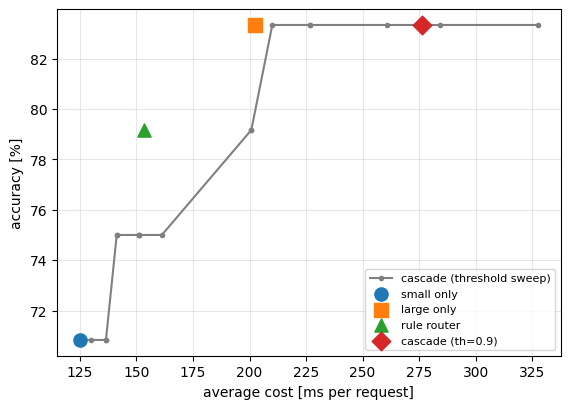

In [28]:
# 規則ベースのルータとカスケードを評価し、コストと品質の関係を図にする
def route_by_rule(q):
    """数が2つ以上、または13語以上なら大きいモデルへ"""
    return "large" if len(re.findall(r"\d+(?:\.\d+)?", q)) >= 2 or len(q.split()) >= 13 else "small"

def evaluate(choose):
    """choose(row) が "small"、"large"、"both"（小→大の順に両方）を返す、正答率と平均コストを求める"""
    ok, cost, n_large = 0, 0.0, 0
    for r in table:
        c = choose(r)
        ok += r["s_ok"] if c == "small" else r["l_ok"]
        cost += {"small": r["s_time"], "large": r["l_time"], "both": r["s_time"] + r["l_time"]}[c]
        n_large += c != "small"
    return ok / len(table), cost / len(table) * 1e3, n_large / len(table)

results = {"small only": evaluate(lambda r: "small"),
           "large only": evaluate(lambda r: "large"),
           "rule router": evaluate(lambda r: route_by_rule(r["q"]))}
# カスケード: 自信がしきい値より低ければ大きいモデルへ回す、しきい値を動かすと曲線になる
thresholds = np.linspace(0.0, 1.0, 21)
cascade = [evaluate(lambda r: "both" if r["s_conf"] < th else "small") for th in thresholds]
results["cascade (th=0.9)"] = evaluate(lambda r: "both" if r["s_conf"] < 0.9 else "small")

print("%-18s %9s %14s %12s" % ("", "accuracy", "cost [ms/req]", "to large"))
for name, (acc, cost, frac) in results.items():
    print("%-18s %8.0f%% %14.0f %11.0f%%" % (name, acc * 100, cost, frac * 100))
# カスケードのしきい値のうち、大きいモデルだけの場合と同じ正答率に最も安く届くもの
best = min((c[1], th) for c, th in zip(cascade, thresholds) if c[0] >= results["large only"][0])
print("cheapest cascade reaching large-only accuracy: th=%.2f, cost %.0f ms/req" % (best[1], best[0]))

plt.figure(figsize=(6.5, 4.5))
plt.plot([c[1] for c in cascade], [c[0] * 100 for c in cascade], ".-", color="gray", label="cascade (threshold sweep)")
for (name, (acc, cost, _)), m in zip(results.items(), ["o", "s", "^", "D"]):
    plt.scatter([cost], [acc * 100], marker=m, s=90, label=name, zorder=3)
plt.xlabel("average cost [ms per request]"); plt.ylabel("accuracy [%]")
plt.grid(alpha=0.3); plt.legend(fontsize=8, loc="lower right"); plt.show()

## 結果の読み方

図の左上ほど良い（安くて正確）

- **small only** と **large only** が両端である
    - 小さいモデルは安いが正答率が低く、大きいモデルはその逆である
- **rule router** は両者の間に入る
    - 大きいモデルへ送る要求を半分ほどに減らしながら、正答率は大きいモデルだけの場合に近い
    - 完全には一致しない
        - 規則が「難しい」と見抜けなかった質問を小さいモデルが間違えるためである
- **cascade** は、しきい値を上げるほど大きいモデルへ回す要求が増え、正答率もコストも上がる（灰色の折れ線）
    - 著者の環境では、しきい値を最もうまく選んだ場合（0.7）に、大きいモデルだけの場合と同じ正答率に、ほぼ同じコストで届いた（コードの最後の出力を参照）
        - つまり、この2つのモデルの組み合わせでは、カスケードは得になっていない
    - 一方、しきい値0.9（赤い印）は回しすぎで、同じ正答率のままコストが大きいモデルだけの場合を上回った
    - 回した要求では小さいモデルの時間が無駄になるので、回す割合が増えるほど損になる
    - この2つのモデルは処理時間の差が2倍程度しかないので、得をする範囲が狭い
        - モデル間のコストの差が大きく（10倍以上など）、小さいモデルで済む要求が多いほど、カスケードは有利になる
    - 「うまく選んだしきい値」は、この24問の正解を見て選んだものである
        - 別の質問でも同じしきい値が最良とは限らない

この実験から読み取るべきことは3つある

- ルーティングは「品質とコストの中間点」を作り出す手段であり、どの点を選ぶかはSLOと予算で決まる
- 規則は、手元の質問に合わせて作ればいくらでも良く見せられる
    - この規則も24問を見ながら作ったものであり、別の質問で同じ結果になる保証はない
    - 実用では、規則ではなく、難しさを予測する小さな分類器を学習させることが多い
- 自信の値（トークン確率の平均）は、正しさの目安として完全ではない
    - モデルは自信を持って間違えることがある

## フォールバック

ルーティングが「どこへ送るか」を選ぶ仕組みなら、**フォールバック**（fallback）は「送り先が失敗したらどうするか」を決める仕組みである

サーバは必ず失敗する
過負荷、GPUのメモリ不足、プロセスの異常終了、ネットワークの瞬断など、原因はいくらでもある
利用者にエラーを見せないために、クライアント（またはその手前に置く中継サーバ）が次の3段階で粘る

1. **タイムアウト**（timeout）: 決めた時間内に応答が無ければ、あきらめて次の手を打つ
    - タイムアウトが無いと、応答しないサーバを待ち続け、待っている側の資源も尽きる
2. **再試行**（retry）: 一時的な失敗なら、少し待ってもう一度送る
    - 待ち時間は試行のたびに倍にする（指数バックオフ）
        - さらに乱数でずらす（ジッタ）
    - 全員が同じ間隔で再試行すると、回復しかけたサーバに要求が同時に押し寄せて再び倒れるためである
3. **フォールバック**: それでも失敗するなら、別の系（予備のサーバ、別のモデル、別のリージョン）へ送る
    - 予備が小さいモデルなら品質は下がるが、エラーを返すよりはよい

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-retry-fallback.png" width=720>

上の図は、主系が失敗し続けた場合の1件の要求の経過を、時間軸に沿って描いたものである

実験のために、2つのサーバを立てる

- `v1`: 正常なサーバ
- `v2`: `FAIL_RATE=0.2` で2割の要求にエラーを返し、`EXTRA_DELAY_MS=300` で応答も遅い、不調なサーバ

In [29]:
# 正常なサーバ v1 と、不調を模擬したサーバ v2 を起動する
LOG = "canary_log.jsonl"
if os.path.exists(LOG):
    os.remove(LOG)
print(start_server(PORT_A, VERSION="v1", MAX_BATCH=8, LOG_PATH=LOG))
print(start_server(PORT_B, VERSION="v2", MAX_BATCH=8, LOG_PATH=LOG, FAIL_RATE=0.2, EXTRA_DELAY_MS=300))

{'status': 'ok', 'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'version': 'v1', 'max_batch': 8, 'queue_depth': 0}
{'status': 'ok', 'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'version': 'v2', 'max_batch': 8, 'queue_depth': 0}


In [30]:
# タイムアウト、再試行、フォールバックを備えた呼び出しを定義し、成功率を比べる
def robust_chat(prompt, ports, max_tokens=16, timeout=10, retries=0, backoff=0.1):
    """ports を順に試す、各ポートで retries 回まで再試行し、だめなら次のポートへ移る"""
    attempts = 0
    for port in ports:
        for k in range(retries + 1):
            attempts += 1
            wait = backoff * 2 ** k                                    # 指数バックオフ
            try:
                r = requests.post(f"http://127.0.0.1:{port}/v1/chat/completions", timeout=timeout,
                                  json={"messages": [{"role": "user", "content": prompt}], "max_tokens": max_tokens})
                if r.status_code == 200:
                    return r.json(), port, attempts
                if r.status_code == 400:                               # 要求が悪い場合は再試行しても無駄
                    return None, port, attempts
                wait = max(wait, float(r.headers.get("Retry-After", 0)))   # サーバの指示があれば従う
            except requests.RequestException:
                pass
            if k < retries:
                time.sleep(wait + random.uniform(0, backoff))          # ジッタを加えて待つ
    return None, None, attempts

N_TRY = 50
policies = {"v1 only": dict(ports=[PORT_A]),
            "v2 only": dict(ports=[PORT_B]),
            "v2 + 1 retry": dict(ports=[PORT_B], retries=1),
            "v2 + 1 retry + fallback to v1": dict(ports=[PORT_B, PORT_A], retries=1)}
print("%-32s %9s %10s %12s" % ("", "success", "attempts", "served by v1"))
for name, kw in policies.items():
    out = [robust_chat(PROMPTS[i % len(PROMPTS)], **kw) for i in range(N_TRY)]
    print("%-32s %8.0f%% %10.2f %11.0f%%" % (
        name, 100 * np.mean([o[0] is not None for o in out]), np.mean([o[2] for o in out]),
        100 * np.mean([o[1] == PORT_A for o in out])))

                                   success   attempts served by v1
v1 only                               100%       1.00         100%
v2 only                                92%       1.00           0%
v2 + 1 retry                           98%       1.12           0%
v2 + 1 retry + fallback to v1         100%       1.34           8%


## 結果の読み方

- 何もしなければ、サーバの失敗率がそのまま利用者に見える失敗率になる
    - 50件しか送っていないので、観測される失敗率は設定した2割からずれる
        - 少ない件数で割合を語るときは常にこの誤差がある
- 1回の再試行で、失敗率はおおよそ「失敗率の2乗」まで下がる
    - 失敗が互いに独立な場合の話である
        - サーバが完全に落ちているときは、何度再試行しても成功しない
- フォールバックを加えると、主系がどれだけ不調でも、予備系が生きていれば応答を返せる

再試行には副作用がある

- **負荷が増える**: 平均の試行回数が1を超えた分だけ、サーバへの要求が増える
    - 過負荷で失敗しているサーバに再試行を重ねると、負荷をさらに増やして回復を妨げる
    - そのため、再試行の回数には上限を設け、失敗が続く送り先にはしばらく送らない仕組み（サーキットブレーカ）を併用する
- **二重実行**: 「処理は成功したが応答だけが届かなかった」場合、再試行すると同じ処理が2回走る
    - 文章の生成なら害は少ないが、LLMが外部の操作（送金、メール送信など）を行う場合は致命的である
    - 何度実行しても結果が同じになる性質（冪等性）を、要求のIDなどで保証する必要がある

---

# 9. 監視と段階的な公開

サーバを立てて終わりではない
動いているサービスは、**壊れていないことを確かめ続ける**必要がある

## 何をログに残すか

`serve_app.py` は、1件の要求につき1行のJSONをログに書いている
残している項目と、その理由を整理する

| 項目 | 例 | 何に使うか |
| --- | --- | --- |
| 時刻、要求のID | `ts`、`id` | 利用者からの問い合わせと突き合わせる |
| 版 | `version` | どの版のモデルやサーバが応答したかを区別する |
| 結果 | `status`、`finish_reason` | 誤り率を計算する、`length` が多ければ `max_tokens` が足りていない |
| トークン数 | `prompt_tokens`、`completion_tokens` | コストの計算、利用の傾向の把握 |
| 時間の内訳 | `queue_ms`、`ttft_ms`、`total_ms` | 遅い原因が待ち行列か生成かを切り分ける |
| バッチの大きさ | `batch_size` | バッチ処理が効いているかを確かめる |

**プロンプトと応答の本文は、このログには書いていない**

- 本文には個人情報や機密が含まれうる
    - 残す場合は、利用者の同意、保存期間、閲覧できる人の範囲を決める必要がある
- 一方で、品質の問題（おかしな応答）を調べるには本文が必要になる
- 何を残すかは、技術だけでなく規約と法令に関わる設計判断である

学習の監視では損失の曲線を見た（「運用」の章のwandb）
提供の監視では、次の4つを見るのが定石である

- **遅延**（p50、p95、p99）
- **流量**（毎秒リクエスト数）
- **誤り率**
- **飽和度**（待ち行列の長さ、GPUメモリの使用率）

ここでのログは「1件の要求につき1行」であり、サーバの外から見た振る舞いを記録している
LLMがツールを呼びながら何ステップも進むエージェントでは、1つの依頼の内側で何が起きたかも記録する必要がある
その記録（トレースとスパン）の取り方は、「LLM-5 Agent設計」の章の「可観測性」を参照

先ほどのフォールバックの実験で、すでにログがたまっている
読み込んで、版ごとに集計する

In [31]:
# ログを読み込み、版ごとに誤り率と遅延を集計する
def read_log(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

def report(logs):
    """版ごとの件数、誤り率、遅延を表示し、集計結果を返す"""
    out = {}
    print("%-4s %6s %8s %10s %10s %10s %11s" % ("", "n", "errors", "queue p50", "TTFT p50", "total p50", "total p95"))
    for v in sorted({r["version"] for r in logs}):
        rows = [r for r in logs if r["version"] == v]
        ok = [r for r in rows if r["status"] == 200]
        out[v] = {"n": len(rows), "errors": len(rows) - len(ok),
                  "p50": pct([r["total_ms"] for r in ok], 50), "p95": pct([r["total_ms"] for r in ok], 95)}
        print("%-4s %6d %7.1f%% %8.0fms %8.0fms %8.0fms %9.0fms" % (
            v, len(rows), 100 * out[v]["errors"] / len(rows), pct([r["queue_ms"] for r in ok], 50),
            pct([r["ttft_ms"] for r in ok], 50), out[v]["p50"], out[v]["p95"]))
    return out

logs = read_log(LOG)
print("log example:", logs[0], "\n")
_ = report(logs)

log example: {'ts': 1791434444.7019112, 'id': 'chatcmpl-9a9855f578eb', 'version': 'v1', 'status': 200, 'finish_reason': 'length', 'prompt_tokens': 44, 'completion_tokens': 16, 'batch_size': 1, 'queue_ms': 35.50230499990903, 'ttft_ms': 194.06970199997886, 'total_ms': 680.4777969999805} 

          n   errors  queue p50   TTFT p50  total p50   total p95
v1       54     0.0%       11ms       47ms      524ms       704ms
v2      169    16.6%      311ms      349ms      846ms      1018ms


- `v2` の誤り率が高く、遅延も大きいことが、ログだけから読み取れる
- `queue_ms`（待ち行列）と `ttft_ms` を比べると、`v2` の遅さは生成そのものではなく、生成が始まる前の待ちにあることが分かる

実運用では、この集計を数十秒ごとに自動で行い、時系列のグラフにする
指標の収集にはPrometheus、表示にはGrafanaのような道具が広く使われている
さらに、「誤り率が5分間続けて1%を超えたら担当者に通知する」のような**アラート**を、SLOから逆算して設定する

## カナリア公開とA/B試験

新しい版（新しいモデル、新しい量子化設定、新しいサーバの実装）を公開するとき、全利用者を一度に切り替えるのは危険である
手元の試験では問題が無くても、本番の要求の分布では遅い、誤る、ということが起こる

**カナリア公開**（canary release）は、新しい版を**ごく一部の要求にだけ**当てて様子を見る方法である

1. 要求の数%だけを新しい版へ送る
2. 誤り率と遅延を、現行の版と比べる
3. 問題が無ければ割合を段階的に増やす（5% → 25% → 50% → 100%）
4. 問題があれば、割合を0に戻す（ロールバック）

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-canary.png" width=720>

上の図のように、要求を2つの版に振り分け、両方のログを比べて次の一手を決める

問題が起きても、影響を受ける利用者は一部で済む
名前は、炭鉱で有毒ガスをいち早く検知するために連れて行ったカナリアに由来する

先ほどの `v2` を「これから公開したい新しい版」とみなし、要求の20%だけを `v2` へ送る
ログを集計し、あらかじめ決めた基準で、公開を進めるか戻すかを判定する

判定には統計的な検定も使う
誤りが数件多いだけなら偶然かもしれないので、2つの版の誤り率の差が偶然で説明できるかを、比率の差の検定（$z$ 検定）で確かめる

In [32]:
# 要求の20%を新しい版 v2 に送り、ログから公開を進めるか戻すかを判定する
os.remove(LOG)                                   # ここからの要求だけを集計する
CANARY_FRACTION = 0.2
rng = random.Random(SEED)

def canary_request(i):
    port = PORT_B if rng.random() < CANARY_FRACTION else PORT_A
    robust_chat(PROMPTS[i % len(PROMPTS)], ports=[port], max_tokens=24)

with ThreadPoolExecutor(4) as ex:
    list(ex.map(canary_request, range(200)))

stats = report(read_log(LOG))
a, b = stats["v1"], stats["v2"]

# 誤り率の差の検定（帰無仮説: 2つの版の誤り率は等しい）
p_pool = (a["errors"] + b["errors"]) / (a["n"] + b["n"])
se = math.sqrt(p_pool * (1 - p_pool) * (1 / a["n"] + 1 / b["n"]))
z = (b["errors"] / b["n"] - a["errors"] / a["n"]) / se if se > 0 else 0.0
p_value = 0.5 * math.erfc(z / math.sqrt(2))      # 片側（v2 のほうが悪い）
print("\nerror rate: v1 %.1f%%, v2 %.1f%% (z = %.2f, p = %.4f)" % (
    100 * a["errors"] / a["n"], 100 * b["errors"] / b["n"], z, p_value))

# 判定の基準は、公開を始める前に決めておく
bad_errors = p_value < 0.05
bad_latency = b["p50"] > 1.2 * a["p50"]
print("p50 latency: v1 %.0f ms, v2 %.0f ms" % (a["p50"], b["p50"]))
print("decision:", "ROLLBACK" if bad_errors or bad_latency else "PROMOTE (increase the fraction)")

          n   errors  queue p50   TTFT p50  total p50   total p95
v1      167     0.0%       10ms       50ms      976ms      1675ms
v2       33    15.2%      313ms      424ms     1894ms      2713ms

error rate: v1 0.0%, v2 15.2% (z = 5.09, p = 0.0000)
p50 latency: v1 976 ms, v2 1894 ms
decision: ROLLBACK


## 結果の読み方

- `v2` に当たったのは全体の約2割で、利用者の大半は `v1` の応答を受け取っている
- それでも、`v2` の誤り率が高いことは、この件数で十分に検出できた（$p$ 値が非常に小さい）
- 遅延は中央値で比べた
    - `v2` に当たった要求は数十件しかないので、p95のような裾の指標は1〜2件の値で決まってしまい安定しない
    - カナリアの割合が小さいほど、判定に必要な件数が集まるまで時間がかかる
        - 割合と観察時間は組で決める
- 基準に従って「戻す」と判定された
    - 全面公開していれば、全利用者の要求の一部が失敗していた

**判定の基準は、結果を見る前に決めておく**
結果を見てから基準を考えると、都合のよい解釈をしてしまう

## A/B試験との違い

仕組みはカナリア公開と同じ（要求を割合で振り分ける）だが、目的が違う

| | カナリア公開 | A/B試験 |
| --- | --- | --- |
| 目的 | 新しい版が**壊れていないか**を確かめる | 新しい版が**より良いか**を確かめる |
| 見る指標 | 誤り率、遅延 | 利用者の行動（評価ボタン、継続率、課題の達成率） |
| 期間 | 数分〜数時間 | 数日〜数週間 |
| 割合 | 小さく始めて増やす | 多くは半々で固定する |

LLMでは、遅延や誤り率が同じでも**応答の質**が変わりうる
質は自動では測りにくいので、利用者の反応を統計的に比べるA/B試験が必要になる

実際の公開は、次の順に関門を置く

1. **回帰試験**: 公開の前に、手元の評価データで新しい版を採点し、現行の版より悪化していないことを確かめる（「LLM-4 評価」の章の「回帰試験として回す」を参照）
2. **カナリア公開**: 本番の要求の一部で、壊れていないこと（誤り率、遅延）を確かめる
3. **A/B試験**: 本番の利用者の反応で、より良いことを確かめる

「新しい版」は、サーバの実装や量子化の設定だけでなく、調整し直したモデル（「NLP-8 LLM調整」の章）であることも多い
調整は、狙った振る舞いを改善する一方で、別の能力を損なうことがある（同章の「破滅的忘却」）ので、回帰試験を通してからカナリア公開に進む

その際は、同じ利用者が常に同じ版に当たるようにする
乱数ではなく利用者IDのハッシュ値で振り分けると、要求のたびに応答の傾向が変わる混乱を避けられる

## レート制限

1人の利用者（あるいは暴走したプログラム）が大量の要求を送ると、他の全員が遅くなる
**レート制限**（rate limiting）は、受け付ける要求の速さに上限を設けて、これを防ぐ

`serve_app.py` は**トークンバケット**（token bucket）という方式を実装している
ここでの「トークン」は入場券のことで、LLMのトークンとは関係がない

- バケツに、毎秒 `RATE_LIMIT_RPS` 枚の入場券が補充される
- バケツには最大 `RATE_BURST` 枚まで貯まる
- 要求が来たら入場券を1枚使う
    - 無ければ、ステータス `429`（Too Many Requests）で即座に断る

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-token-bucket.png" width=600>

上の図がトークンバケットの仕組みである

貯めておける分だけ、短時間の集中（バースト）は許される
平均の速さだけを制限し、瞬間的な集中は受け入れる、という性質が実際の利用に合っている

断るときは `Retry-After` ヘッダで「何秒後に来てほしいか」を伝える
`robust_chat` は、この指示に従って待つように書いてある

実験のために `v2` を止め、毎秒5件の制限をかけたサーバを立てる
30件を一斉に送り、再試行しない場合と、する場合を比べる

In [33]:
# レート制限つきのサーバを立て、一斉に要求を送る、再試行の有無で結果を比べる
print(start_server(PORT_B, VERSION="limited", MAX_BATCH=8, RATE_LIMIT_RPS=5, RATE_BURST=5, LOG_PATH="limit_log.jsonl"))

def burst(retries):
    t0 = time.perf_counter()
    with ThreadPoolExecutor(30) as ex:
        out = list(ex.map(lambda i: robust_chat(PROMPTS[i % len(PROMPTS)], ports=[PORT_B], max_tokens=8,
                                                retries=retries), range(30)))
    return sum(o[0] is not None for o in out), np.mean([o[2] for o in out]), time.perf_counter() - t0

time.sleep(1.5)                                  # 入場券が貯まるのを待つ
ok, att, wall = burst(retries=0)
print("no retry : %2d/30 accepted, %.2f attempts/request, %.1f s" % (ok, att, wall))
time.sleep(1.5)
ok, att, wall = burst(retries=8)
print("retry    : %2d/30 accepted, %.2f attempts/request, %.1f s" % (ok, att, wall))

{'status': 'ok', 'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'version': 'limited', 'max_batch': 8, 'queue_depth': 0}
no retry :  5/30 accepted, 1.00 attempts/request, 0.4 s
retry    : 30/30 accepted, 3.50 attempts/request, 6.8 s


## 結果の読み方

- 再試行しない場合、通ったのは貯まっていた入場券の分（と、送っている間に補充された分）だけで、残りは `429` で断られた
- 再試行する場合、全件が最終的に通ったが、全体の時間は「件数 ÷ 毎秒の上限」程度まで延びた
    - レート制限は、要求を**消す**のではなく、時間方向に**ならす**働きをする

実際のサービスでは、制限は利用者ごと（APIキーごと）にかける
また、LLMでは1件の要求の重さが大きく違うので、要求の件数だけでなく**トークン数**（毎分何トークンまで）でも制限するのが一般的である

In [34]:
# 後始末: 起動したサーバをすべて停止する
stop_all()
print("running servers:", list(servers))

running servers: []


実験が終わったら、必ずサーバを止める
止め忘れたプロセスはGPUメモリを占有し続け、共有サーバでは他の利用者の迷惑になる（「運用」の章の「プロセスが残留してGPUメモリを占有」を参照）

ノートブックの途中でエラーが起きた場合も、このセルだけは実行しておくこと

---

# 10. コストの見積もり

最後に、ここまで測った数値をお金に換算する

## 1リクエストあたりの原価

GPUは、要求が来ても来なくても、借りている時間の分だけ費用がかかる
したがって原価は「GPUの時間単価」を「その時間に処理できた量」で割れば求まる

出力1トークンあたりの原価は次の式になる

$$
c_{\text{token}} = \frac{P_{\text{GPU}}}{3600 \times T \times u}
$$

- $P_{\text{GPU}}$: GPUの1時間あたりの価格
- $T$: SLOを守れる範囲でのスループット [トークン/秒]（4節で測った値）
- $u$: **稼働率**（utilization）
    - GPUが実際に要求を処理している時間の割合（0〜1）

1リクエストあたりの原価は、平均の出力トークン数 $n_{\text{out}}$ を掛ければよい

$$
c_{\text{request}} = c_{\text{token}} \times n_{\text{out}}
$$

稼働率 $u$ が式に入っていることが重要である

- 利用には波がある
    - 昼の最大値に合わせてGPUを用意すると、夜はほとんど空いている
- 遅延のSLOを守るには、待ち行列が伸びないように余裕を持たせる必要がある
- そのため、稼働率が1になることはなく、**空いている時間の費用も、処理した要求が負担する**

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-cost-structure.png" width=700>

上の図は、GPUを借りた1時間のうち、実際に要求を処理しているのは一部であることを示している

以下の価格はすべて**仮の値**である
実際の価格は事業者や時期で大きく変わるので、変数を書き換えて計算し直すこと

In [35]:
# 測ったスループットから、1トークンと1リクエストあたりの原価を計算する
GPU_PRICE_PER_HOUR = 1.0      # 仮の値: GPU 1台の1時間あたりの価格（通貨の単位は任意）
UTILIZATION = 0.4             # 仮の値: 稼働率
N_OUT = 300                   # 仮の値: 1リクエストの平均出力トークン数

def cost_per_token(throughput_tok_s, price=GPU_PRICE_PER_HOUR, u=UTILIZATION):
    return price / (3600 * throughput_tok_s * u)

T_SERIAL = max(r["tok_s"] for r in res_serial)     # 4節の実測値（逐次処理）
T_BATCH = max(r["tok_s"] for r in res_batch)       # 4節の実測値（動的バッチ）
print("%-16s %12s %22s %18s" % ("", "tokens/s", "cost per 1M tokens", "cost per request"))
for name, T in [("serial", T_SERIAL), ("dynamic batch", T_BATCH)]:
    c = cost_per_token(T)
    print("%-16s %12.1f %22.3f %18.6f" % (name, T, c * 1e6, c * N_OUT))
print("\n稼働率による違い（動的バッチ）")
for u in [0.1, 0.2, 0.4, 0.8]:
    print("  utilization %.1f: cost per 1M tokens %.3f" % (u, cost_per_token(T_BATCH, u=u) * 1e6))

                     tokens/s     cost per 1M tokens   cost per request
serial                   31.1                 22.300           0.006690
dynamic batch           238.8                  2.909           0.000873

稼働率による違い（動的バッチ）
  utilization 0.1: cost per 1M tokens 11.634
  utilization 0.2: cost per 1M tokens 5.817
  utilization 0.4: cost per 1M tokens 2.909
  utilization 0.8: cost per 1M tokens 1.454


## 結果の読み方

- 同じGPU、同じモデルでも、バッチ処理の有無で原価が数倍変わる
    - **スループットを上げる工夫は、そのまま原価を下げる工夫である**
- 稼働率が半分になると、原価は2倍になる
    - 技術的な最適化と同じくらい、「GPUを空けておかないこと」が効く

ここで使ったスループットは、小さいモデルを小さい負荷で測った値である
実際の見積もりでは、提供したいモデルと、実際の要求の長さの分布で測り直す必要がある
また、プロンプトの処理（prefill）にも時間がかかるので、入力が長いサービスでは入力トークンの分も原価に含める

## 自前運用とAPI利用の損益分岐

LLMを使う方法は、大きく2つある

- **API利用**: 事業者が提供するLLMを、トークン数に応じた従量課金で使う
- **自前運用**: GPUを借りる（または買う）して、公開モデルを自分で提供する

費用の構造が違う

| | API利用 | 自前運用 |
| --- | --- | --- |
| 費用の形 | 使った分だけ（変動費） | 使わなくてもかかる（固定費） |
| 少量のとき | 安い | 高い（GPUが空いている） |
| 大量のとき | 利用量に比例して増える | GPUを増やすごとに階段状に増える |

月あたりのリクエスト数を $N$ とすると、月額はそれぞれ次のようになる

$$
C_{\text{API}}(N) = N \times \frac{n_{\text{in}} \, p_{\text{in}} + n_{\text{out}} \, p_{\text{out}}}{10^6}
$$

$$
C_{\text{self}}(N) = \left\lceil \frac{N}{N_{\text{GPU}}} \right\rceil \times 720 \, P_{\text{GPU}} + C_{\text{ops}}
$$

- $n_{\text{in}}$、$n_{\text{out}}$: 1リクエストの入力、出力トークン数
- $p_{\text{in}}$、$p_{\text{out}}$: APIの100万トークンあたりの価格
- $N_{\text{GPU}}$: GPU 1台が1か月に処理できるリクエスト数（スループット、稼働率、出力長から決まる）
- $720$: 1か月の時間数（24時間 × 30日）
- $C_{\text{ops}}$: 運用の固定費（監視、障害対応、更新作業にかかる人件費など）

2つの曲線が交わる $N$ が**損益分岐点**である

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-breakeven.png" width=560>

上の図は2つの式の形を示す模式図である
API利用は原点を通る直線、自前運用はGPUを1台増やすたびに段が上がる階段になる

$C_{\text{API}}$ の式は、「LLM-2 Application」の章の「入力トークンと出力トークンの課金」と同じものである
そこでは使う側として費用を減らす工夫を扱った
ここでは、同じ式を「自分で提供した場合の費用」と比べるために使う

API cost per request     : 0.000700
GPU capacity per month   : 8.25e+05 requests
break-even               : not reached in this range


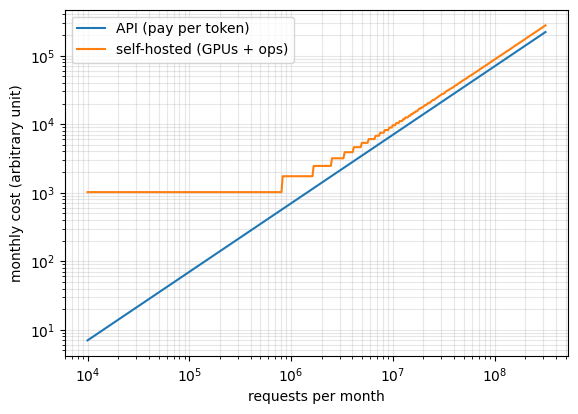

In [36]:
# 自前運用とAPI利用の月額を比べ、損益分岐点を求める（価格はすべて仮の値）
N_IN, N_OUT = 500, 300        # 1リクエストの入力、出力トークン数
API_PRICE_IN = 0.5            # 仮の値: APIの入力100万トークンあたりの価格
API_PRICE_OUT = 1.5           # 仮の値: APIの出力100万トークンあたりの価格
OPS_COST_PER_MONTH = 300.0    # 仮の値: 自前運用の月あたりの固定費
T_SELF = T_BATCH              # 自前運用のスループット [トークン/秒]

api_per_request = (N_IN * API_PRICE_IN + N_OUT * API_PRICE_OUT) / 1e6
gpu_capacity = T_SELF * UTILIZATION * 3600 * 720 / N_OUT          # GPU 1台の月間処理件数

def api_cost(n):
    return n * api_per_request

def self_cost(n):
    return np.ceil(n / gpu_capacity) * 720 * GPU_PRICE_PER_HOUR + OPS_COST_PER_MONTH

n = np.logspace(4, 8.5, 400)
cheaper = n[self_cost(n) < api_cost(n)]
print("API cost per request     : %.6f" % api_per_request)
print("GPU capacity per month   : %.2e requests" % gpu_capacity)
print("break-even               : %s" % ("%.2e requests/month" % cheaper[0] if len(cheaper) else "not reached in this range"))

plt.figure(figsize=(6.5, 4.5))
plt.plot(n, api_cost(n), label="API (pay per token)")
plt.plot(n, self_cost(n), label="self-hosted (GPUs + ops)")
if len(cheaper):
    plt.axvline(cheaper[0], color="gray", ls=":", label="break-even")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("requests per month"); plt.ylabel("monthly cost (arbitrary unit)")
plt.grid(alpha=0.3, which="both"); plt.legend(); plt.show()

## 結果の読み方

- 利用が少ないうちは、API利用のほうが安い
    - 自前運用は、ほとんど空いているGPUと運用の固定費を払い続けることになる
- 利用が増えると、API利用の費用は比例して増え、ある点で自前運用を上回る
- 自前運用の曲線は、GPU 1台の処理能力を超えるたびに階段状に上がる
- 測ったスループットが低い場合や、APIの価格が安い場合は、2つの曲線が交わらない（`not reached` と表示される）
    - 自前運用の1件あたりの原価がAPIの価格を上回っており、どれだけ利用が増えても自前運用は得にならない、という意味である

この図は変数の値でいくらでも変わる
`API_PRICE_OUT` や `OPS_COST_PER_MONTH` を書き換えて、損益分岐点がどう動くかを確かめてほしい

費用だけで決まらない要素も多い

- **品質**: 自前で動かせる公開モデルと、APIで提供されるモデルの品質は同じではない
    - 同じ品質で比べなければ意味がない
- **データの扱い**: 外部に出せないデータを扱うなら、費用にかかわらず自前運用が必要になることがある
- **運用の負担**: この章で扱った監視、段階的な公開、障害対応を、自分たちで担うことになる
- **価格の変化**: LLMのAPI価格もGPUの価格も変化が速い
    - 見積もりは定期的にやり直す

だからこそ、具体的な価格を覚えるのではなく、**式と測り方**を身につけておく

---

# 11. Colabでは実習できない範囲

ここまでは、1台のGPU、1つのプロセスで完結する範囲を扱った
実際のサービスは複数のサーバで構成される
Colabでは試せない3つの話題について、概念と設計上の要点だけをまとめる

## Kubernetesでの自動スケール

**Kubernetes**は、多数のマシンの上でコンテナ（「運用」の章のDockerを参照）を配置、起動、再起動する基盤である
推論サーバを複数の複製（レプリカ）として動かし、手前のロードバランサが要求を振り分ける

<img src="https://class.west.sd.keio.ac.jp/dataai/text/serve-autoscale.png" width=700>

上の図では、起動中のレプリカ3には、準備が整うまで要求が回らない

**自動スケール**（autoscaling）は、負荷に応じてレプリカの数を自動で増減させる仕組みである

- **何を見て増やすか**
    - Webサーバの定番はCPU使用率だが、LLMの推論では役に立たない
        - GPUはバッチが1件でも8件でも「使用中」に見えるためである
    - 待ち行列の長さ、処理中の要求数、TTFTのような、**利用者の待ちに直結する指標**を使う
- **起動の遅さ**
    - 2節で測ったように、モデルの読み込みには時間がかかる
        - 大きいモデルでは、GPUつきのマシンの確保から数分かかることもある
    - 負荷が上がってから増やしても間に合わないので、余裕を持たせる、予測して先に増やす、モデルを高速なストレージに置く、といった対策を取る
- **準備完了の確認**
    - `/health` が通るまで、新しいレプリカに要求を回さない（readiness probe）
- **縮小の難しさ**
    - 生成の途中でレプリカを止めると、利用者の応答が途切れる
        - 新しい要求の受け付けを止め、処理中の要求が終わるのを待ってから止める（graceful shutdown）
    - 要求が無いときにレプリカを0にすれば費用は最小になるが、次の要求は起動を待たされる（コールドスタート）

## 複数リージョン

**リージョン**（region）は、データセンターが置かれた地域である
複数のリージョンにサービスを置く理由は3つある

- **遅延**: 利用者に近い場所で処理すると、通信の往復時間が短くなる
    - ただしLLMでは生成時間が支配的なことが多く、通信の短縮の効果は相対的に小さい
- **可用性**: 1つのリージョン全体が停止しても、他のリージョンで応答を続けられる
    - 8節のフォールバックを、地域の単位で行うことに当たる
- **GPUの確保**: 1つのリージョンで必要な数のGPUを確保できないことがあり、空いている地域へ要求を回す

設計上の要点は次のとおりである

- データを国外に出せない規制がある場合、要求を送ってよいリージョンが制限される
- すべてのリージョンで同じ版のモデルを動かす
    - 版がそろっていないと、同じ質問への応答が場所によって変わる
- 7節のプレフィックスキャッシュは、KVキャッシュを持っているサーバに要求が届かなければ効かない
    - 同じ利用者や同じ対話の要求を同じサーバへ送る振り分けが必要になる

## 障害注入試験

フォールバックや自動スケールは、**実際に障害が起きるまで動くかどうか分からない**
しかも、ふだん使われない経路のコードは、設定の変更などでいつの間にか壊れていることが多い

**障害注入試験**（fault injection）は、わざと障害を起こして、備えが働くことを確かめる試験である
本番に近い環境で継続的に行う取り組みは**カオスエンジニアリング**（chaos engineering）と呼ばれる

本テキストでも、小さな規模で同じことをしていた
`FAIL_RATE` と `EXTRA_DELAY_MS` で不調なサーバを作り、再試行とフォールバックが働くことを確かめた

実際に注入する障害の例を挙げる

- レプリカのプロセスを強制終了する
- ネットワークに遅延や切断を加える
- GPUのメモリ不足を起こす
- 依存している外部サービスを応答不能にする

設計上の要点は次のとおりである

- **仮説を先に書く**: 「レプリカが1つ落ちても、誤り率は0.1%を超えない」のように、期待する結果を決めてから実施する
- **影響範囲を絞る**: カナリア公開と同じく、一部の要求、一部のレプリカから始める
- **すぐ止められるようにする**: 想定外の影響が出たら、即座に中止して元に戻せる手段を用意する

---

# まとめ

本テキストでは、学習済みのLLMを利用者に提供するための技術を、小型モデルで実測しながら学んだ

| 節 | 内容 | 核心 |
| --- | --- | --- |
| 1 | 学習と推論提供の違い | 遅延、スループット、コスト、可用性の綱引きの中で、SLOを満たす最も安い点を探す |
| 2 | 推論サーバ | 受付と生成を待ち行列で分ける、形をOpenAI互換にそろえると背後を取り替えられる |
| 3 | 指標 | TTFTはprefill、ITLはdecodeに対応し、律速が違う、平均ではなくパーセンタイルで見る |
| 4 | バッチ処理 | decodeの余力に要求を相乗りさせる、出力長のばらつきには連続バッチが効く |
| 5 | 専用エンジン | 連続バッチとKVキャッシュのメモリ管理が中核である |
| 6 | 量子化 | メモリは確実に減る、速度と品質は実装と設定によるので測る |
| 7 | キャッシュ | KVキャッシュ、応答キャッシュ、先頭の共有、効果は要求の重なり方で決まる |
| 8 | ルーティングとフォールバック | 簡単な要求を安いモデルへ、失敗にはタイムアウト、再試行、予備系で備える |
| 9 | 監視と段階的な公開 | 1要求1行のログ、新しい版は一部から当て、決めておいた基準で判定する |
| 10 | コスト | 原価 = GPUの時間単価 ÷（スループット × 稼働率） |
| 11 | 実習できない範囲 | 自動スケール、複数リージョン、障害注入試験 |

どの手法にも共通する教訓は1つである

**変更したら測る、測った数値で判断する**

---

# 課題1（開ループの負荷試験）

4節の `load_test` は閉ループであった
到着率を指定する開ループの負荷試験を実装し、以下を報告せよ

1. 到着率 $\lambda$ [件/秒] を引数に取り、要求の間隔を指数分布（平均 $1/\lambda$）で決めて送り続ける関数 `open_loop_test` を実装する（応答を待たずに次を送ること）
2. `MAX_BATCH=8` のサーバに対し、到着率を5段階以上に変えて、スループット、TTFTのp50とp95、総遅延のp95を測る
3. 横軸を到着率、縦軸をp95遅延とした図を描く
4. 遅延が急に伸び始める到着率を読み取り、4節の閉ループの結果から予想される処理能力と比べて考察する
5. 閉ループの試験では見えず、開ループの試験で初めて見える現象は何かを説明する

# 課題2（SLOを満たす設定の探索）

「TTFTのp95が0.5秒以内、総遅延のp95が3秒以内（出力48トークン）」というSLOを仮に定める（測定環境に合わせて値を変えてもよい）

1. `MAX_BATCH` を 1、4、8、16、`BATCH_WAIT_MS` を 0、10、50 に変え、それぞれの組み合わせで負荷試験を行う
2. 各設定について、SLOを満たす最大の同時リクエスト数と、そのときのスループットを表にまとめる
3. SLOを満たす範囲でスループットが最大になる設定を選び、10節の式で100万トークンあたりの原価を計算する
4. `BATCH_WAIT_MS` を大きくしたときに、どの指標が良くなり、どの指標が悪くなったかを、理由とともに説明する

# 課題3（ルータの改良とカナリア公開）

8節と9節を組み合わせ、ルータの改良を安全に公開する手順を実践せよ

1. 8節の評価用の質問に、自分で考えた質問を20問以上追加する（簡単なものと難しいものを半分ずつ、正解つき）
2. 8節の `route_by_rule` を、追加した質問を**見ずに**改良する
    - 改良の方針は自由である（規則の追加、カスケードのしきい値の調整、両者の組み合わせなど）
3. 元のルータと改良したルータについて、追加した質問での正答率と平均コストを求め、コストと品質の図に描き入れる
4. 改良したルータを「新しい版」とみなし、要求の20%だけを新しい版に通すカナリア公開を模擬する
    - 版ごとの正答率と平均コストを集計し、あらかじめ決めた基準で公開を進めるか戻すかを判定する
5. 手順2で質問を見ずに改良することが、なぜ重要なのかを説明する

# 参考文献

- Kwon, W. et al. (2023). "Efficient Memory Management for Large Language Model Serving with PagedAttention." SOSP 2023.
- Yu, G.-I. et al. (2022). "Orca: A Distributed Serving System for Transformer-Based Generative Models." OSDI 2022.
- Crankshaw, D. et al. (2017). "Clipper: A Low-Latency Online Prediction Serving System." NSDI 2017.
- Dean, J. and Barroso, L. A. (2013). "The Tail at Scale." Communications of the ACM, 56(2).
- Dettmers, T. et al. (2022). "LLM.int8(): 8-bit Matrix Multiplication for Transformers at Scale." NeurIPS 2022.
- Dettmers, T. et al. (2023). "QLoRA: Efficient Finetuning of Quantized LLMs." NeurIPS 2023.
- Leviathan, Y. et al. (2023). "Fast Inference from Transformers via Speculative Decoding." ICML 2023.
- Chen, L., Zaharia, M. and Zou, J. (2023). "FrugalGPT: How to Use Large Language Models While Reducing Cost and Improving Performance." arXiv:2305.05176.
- Ong, I. et al. (2024). "RouteLLM: Learning to Route LLMs with Preference Data."
- Basiri, A. et al. (2016). "Chaos Engineering." IEEE Software, 33(3).
- Beyer, B. et al. (2016). "Site Reliability Engineering: How Google Runs Production Systems." O'Reilly Media.
- Huyen, C. (2022). "Designing Machine Learning Systems." O'Reilly Media.
- Sculley, D. et al. (2015). "Hidden Technical Debt in Machine Learning Systems." NeurIPS 2015.
- vLLM Documentation. https://docs.vllm.ai/
- Hugging Face Transformers Documentation. https://huggingface.co/docs/transformers/
- bitsandbytes Documentation. https://huggingface.co/docs/bitsandbytes/
- FastAPI Documentation. https://fastapi.tiangolo.com/
- OpenAI API Reference: Chat Completions. https://platform.openai.com/docs/api-reference/chat
- Qwen2.5-0.5B-Instruct Model Card. https://huggingface.co/Qwen/Qwen2.5-0.5B-Instruct
- Kubernetes Documentation: Horizontal Pod Autoscaling. https://kubernetes.io/docs/tasks/run-application/horizontal-pod-autoscale/
- Prometheus Documentation. https://prometheus.io/docs/